# EDA for Synthetic Travel Itinerary Dataset

This notebook demonstrates how to inspect the synthetic travel‑itinerary CSV that was generated by the previous script.  It loads the data, prints basic statistics, and visualises the most important features.

In [ ]:
%matplotlib inline
# -- Imports ---------------------------------------------------------------
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# -- Settings --------------------------------------------------------------
# Paths relative to ml/notebooks/
CSV_PATH = "../data/itinerary_dataset.csv"
PLOT_DIR : Path = Path("../plots")
REPORT_MD : Path = Path("../reports/eda_report.md")
SUBSAMPLE = None

sns.set(style="whitegrid", palette="deep", rc={'figure.figsize':[10, 5]})
plt.rcParams["figure.dpi"] = 120

In [2]:
# -- Helper to save figures -----------------------------------------------
def save_fig(name: str):
    """Save current matplotlib figure to PLOT_DIR and display it inline."""
    PLOT_DIR.mkdir(exist_ok=True, parents=True)
    fig = plt.gcf()
    fig.savefig(PLOT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [3]:
# -- Load data ---------------------------------------------------------------
print(f"Loading '{CSV_PATH}' …")
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns.")

# preview
df.head()

Loading 'itinerary_dataset.csv' …
Loaded 10,000 rows, 41 columns.


,travel_experience_level,travel_frequency,engagement_level,culture,food,nature,adventure,relaxation,shopping,nightlife,...,poi_rating,poi_popularity_score,poi_visit_duration_minutes,poi_cost_level,ai_itinerary_accepted,ai_itinerary_modified,attraction_viewed_count,trip_planner_invoked_count,user_engagement_score,itinerary_completion_rate
0,expert,few times a year,high,0.40,0.24,0.42,0.32,0.56,0.95,0.90,...,4.0,0.182,79,medium,False,True,44,3,0.47,0.91
1,novice,few times a year,medium,0.56,0.99,0.97,0.30,0.38,0.84,0.32,...,5.0,0.551,128,low,True,False,24,1,0.61,0.79
2,intermediate,rarely,medium,0.33,0.55,0.10,0.11,0.71,0.71,0.15,...,3.6,0.714,122,low,True,False,43,2,0.50,0.81
3,intermediate,few times a year,low,0.11,0.23,0.33,0.25,0.14,0.15,0.12,...,4.8,0.720,139,low,False,False,13,4,0.42,0.92
4,novice,few times a year,high,0.99,0.86,0.58,0.33,0.73,0.73,0.55,...,3.7,0.515,140,low,True,False,13,2,0.72,0.94


In [4]:
# -- Basic statistics -------------------------------------------------------
df.describe(include=[np.number]).round(2)

,culture,food,nature,adventure,relaxation,shopping,nightlife,trip_duration_days,distance_km,estimated_time_minutes,...,budget_utilization_ratio,destination_popularity_score,ai_suggestion_acceptance_rate,poi_rating,poi_popularity_score,poi_visit_duration_minutes,attraction_viewed_count,trip_planner_invoked_count,user_engagement_score,itinerary_completion_rate
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,0.50,0.49,0.50,0.50,0.50,0.50,0.50,8.51,1096.54,1646.33,...,0.95,0.70,0.70,4.24,0.50,105.26,27.58,2.98,0.50,0.85
std,0.29,0.29,0.29,0.29,0.29,0.29,0.29,4.05,1797.59,2710.82,...,0.15,0.17,0.12,0.44,0.29,43.33,13.21,1.41,0.15,0.09
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,10.00,12.00,...,0.70,0.40,0.50,3.50,0.00,30.00,5.00,1.00,0.00,0.70
25%,0.25,0.24,0.24,0.26,0.25,0.24,0.26,5.00,104.00,155.00,...,0.82,0.55,0.60,3.90,0.26,68.00,16.00,2.00,0.40,0.77
50%,0.50,0.49,0.50,0.50,0.50,0.49,0.51,8.50,199.00,309.00,...,0.95,0.70,0.70,4.30,0.50,105.00,28.00,3.00,0.50,0.85
75%,0.75,0.74,0.74,0.75,0.75,0.74,0.75,12.00,1167.00,1737.25,...,1.08,0.85,0.80,4.60,0.75,143.00,39.00,4.00,0.60,0.92
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,15.00,7995.00,13843.00,...,1.20,1.00,0.90,5.00,1.00,180.00,50.00,5.00,1.00,1.00


### Value‑counts for categorical columns
- Look at the number of unique values in each object column.

In [5]:
for col in df.select_dtypes(include='object'):
    print(f"{col}: {df[col].nunique()} unique values")

travel_experience_level: 3 unique values
travel_frequency: 3 unique values
engagement_level: 3 unique values
country_code: 10 unique values
country_name: 10 unique values
city: 30 unique values
season: 4 unique values
group_size: 5 unique values
transport_mode: 6 unique values
destination_type: 6 unique values
traffic_condition: 4 unique values
budget_tier: 4 unique values
group_size_category: 2 unique values
distance_category: 3 unique values
daily_activities: 10000 unique values
poi_category: 6 unique values
poi_cost_level: 3 unique values


### Histograms for numeric variables
Feel free to adjust the number of bins or add density curves if you like.

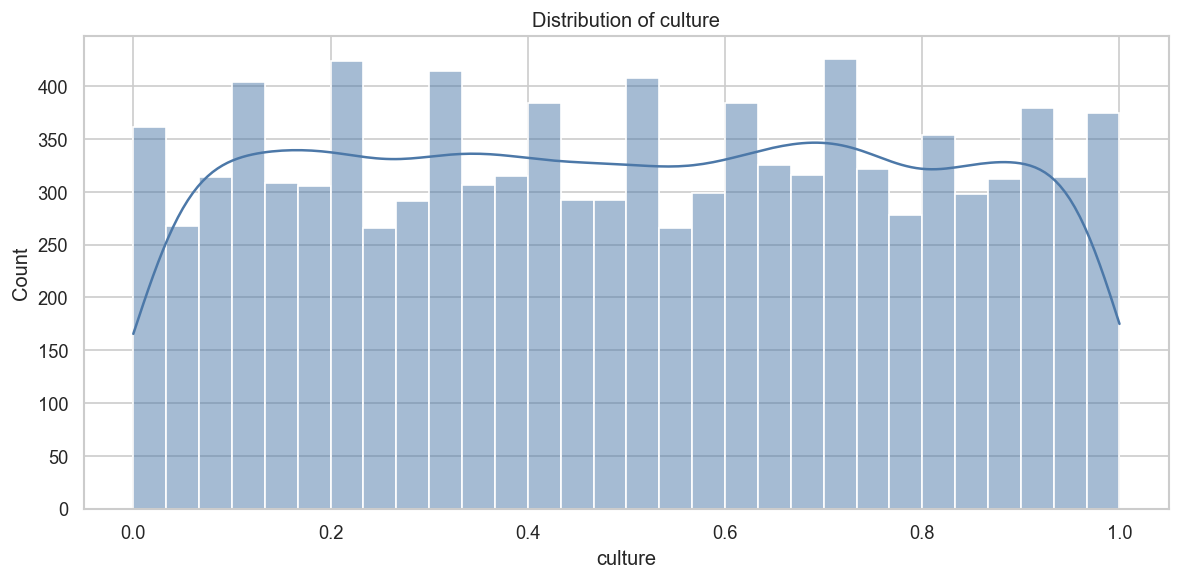

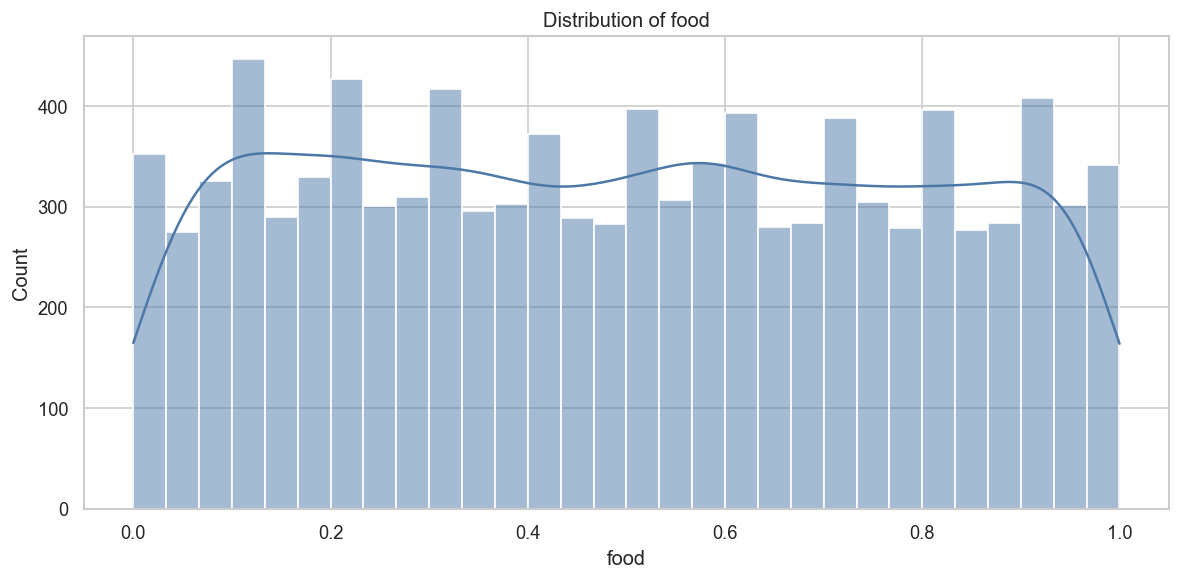

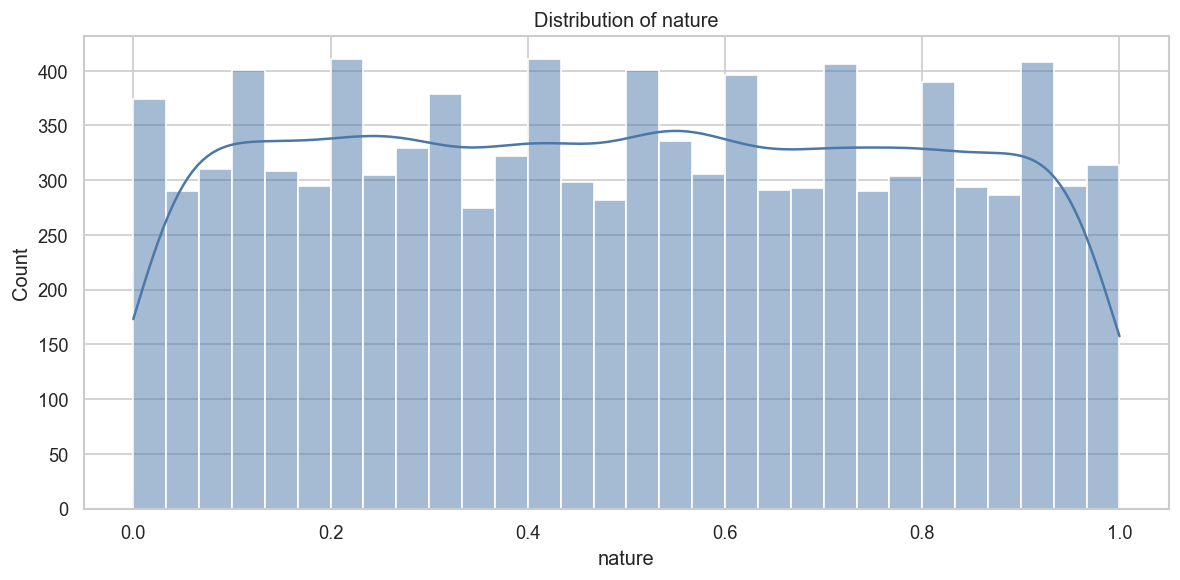

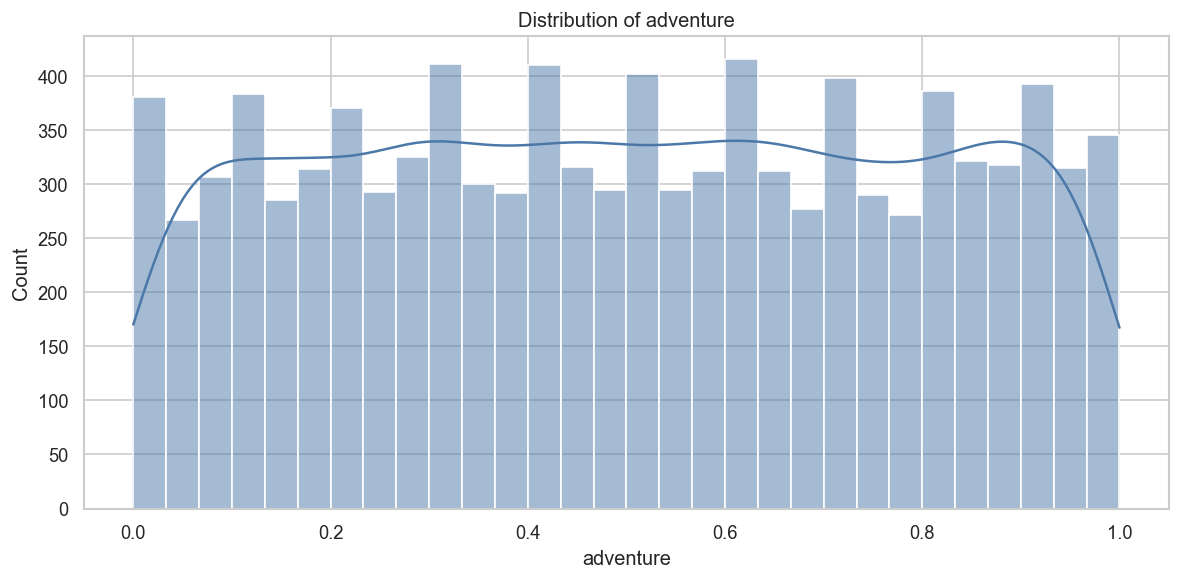

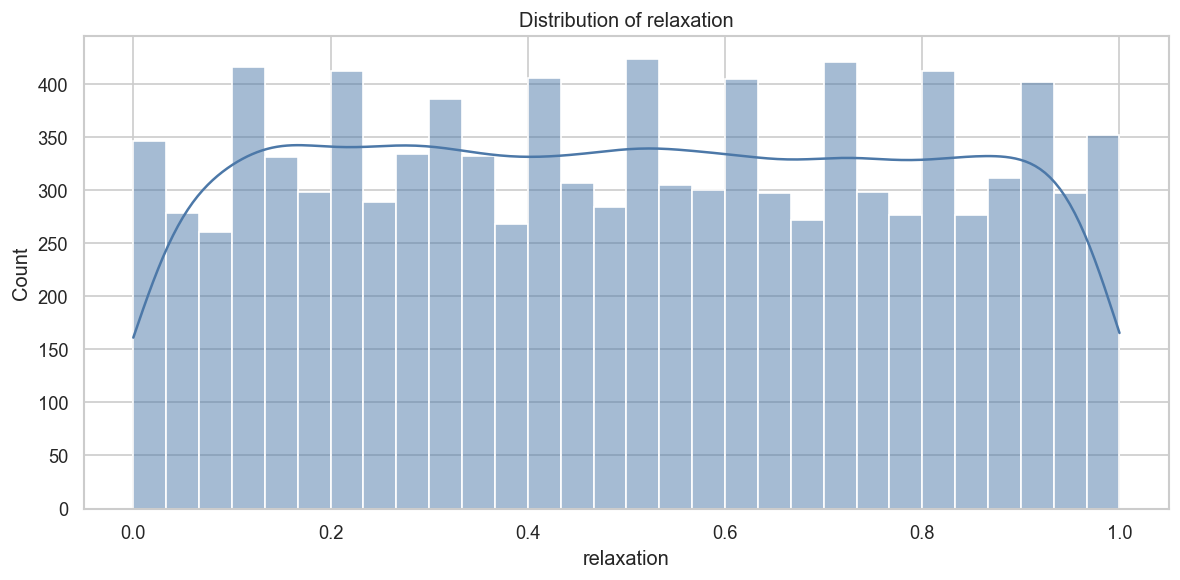

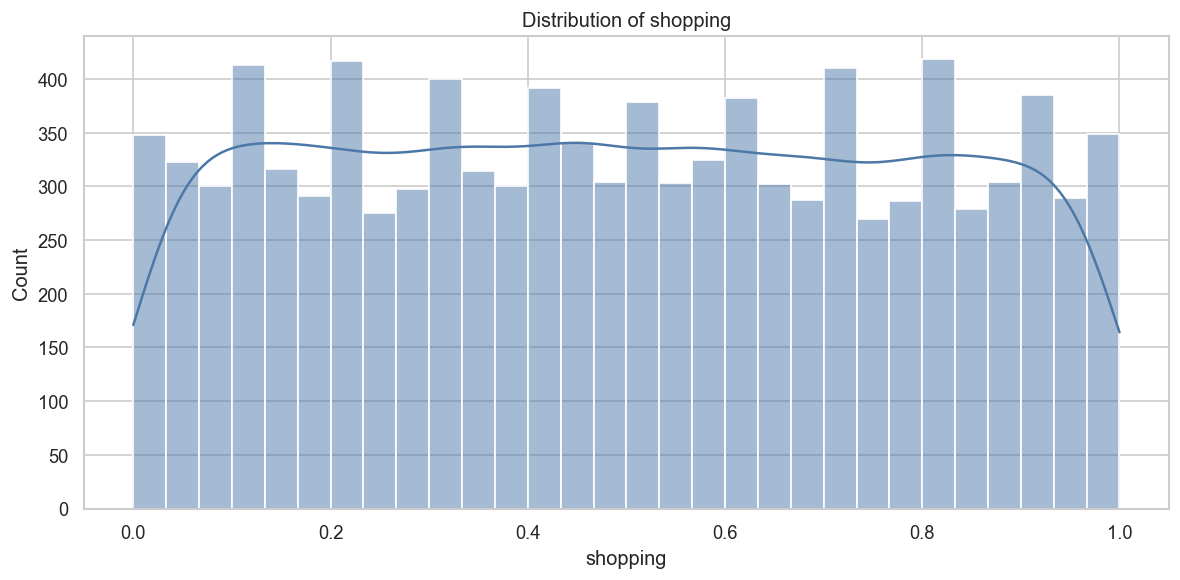

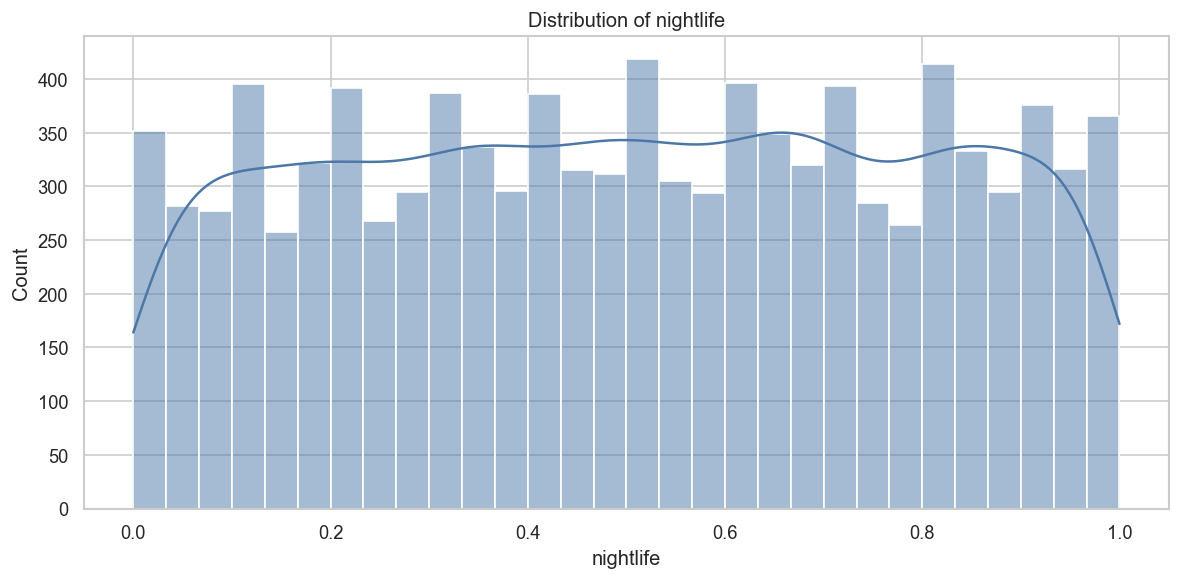

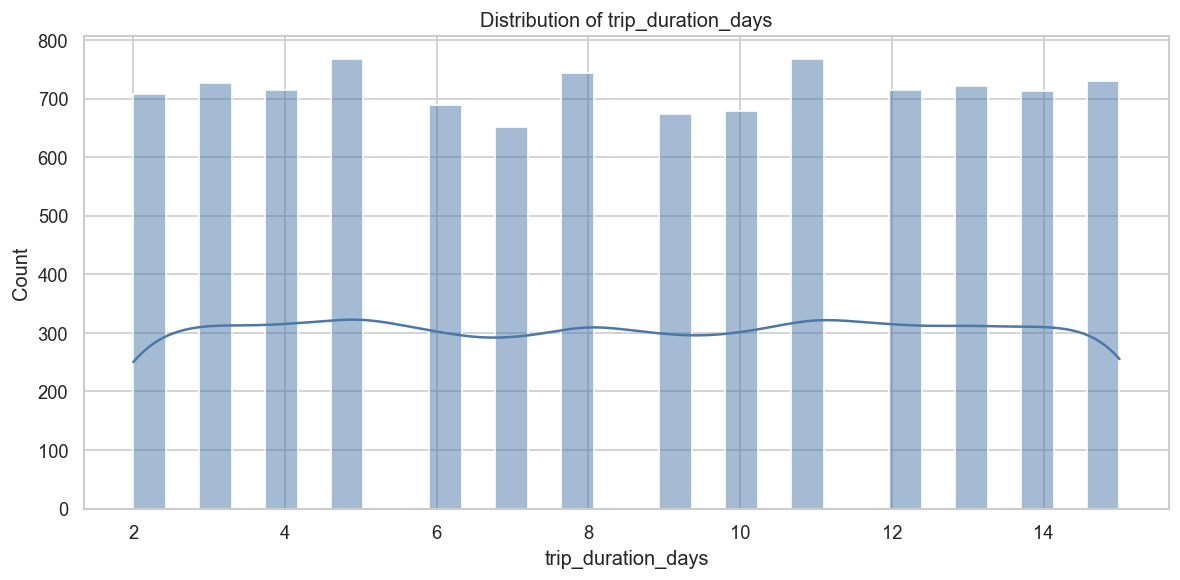

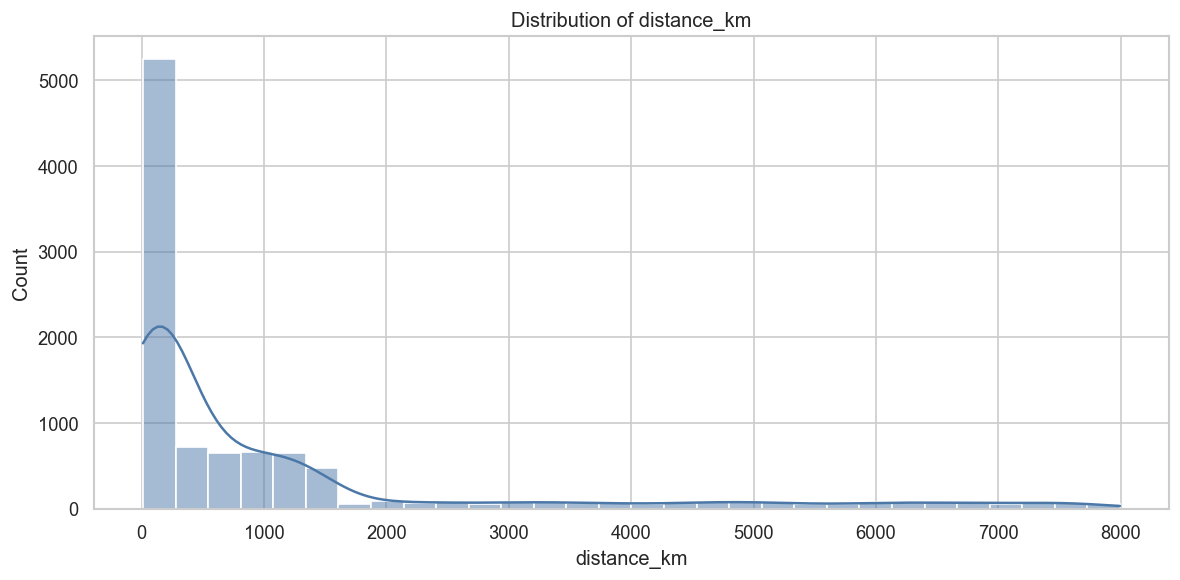

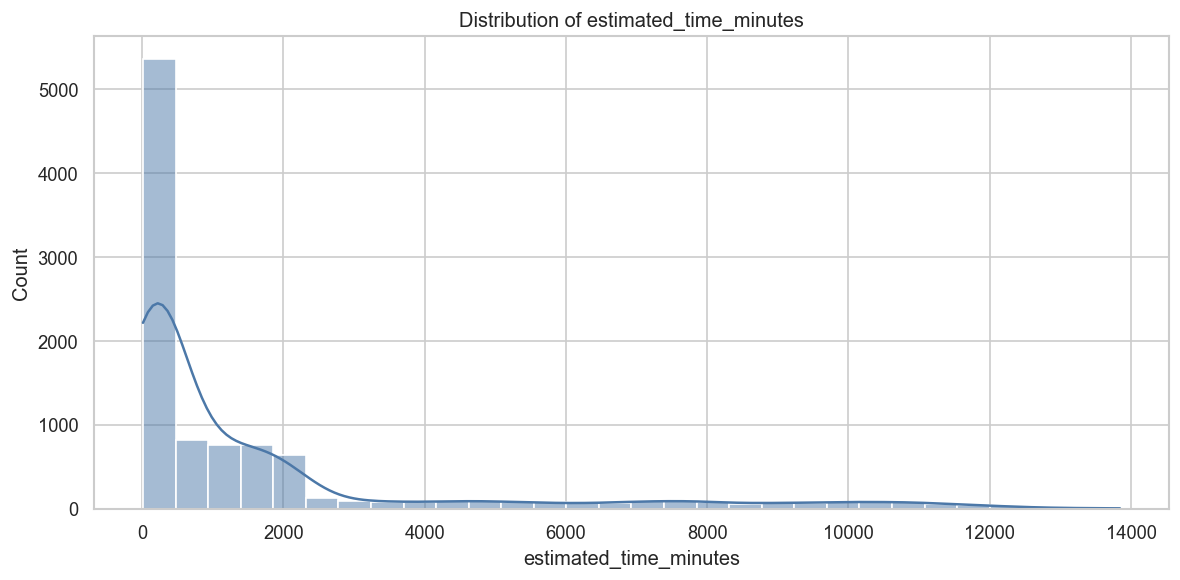

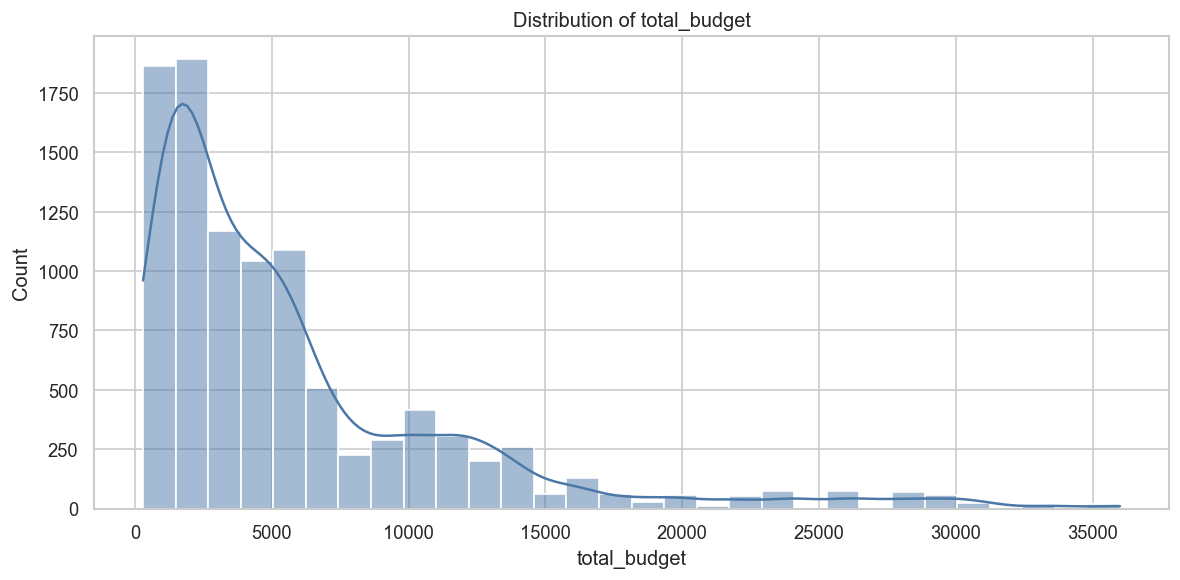

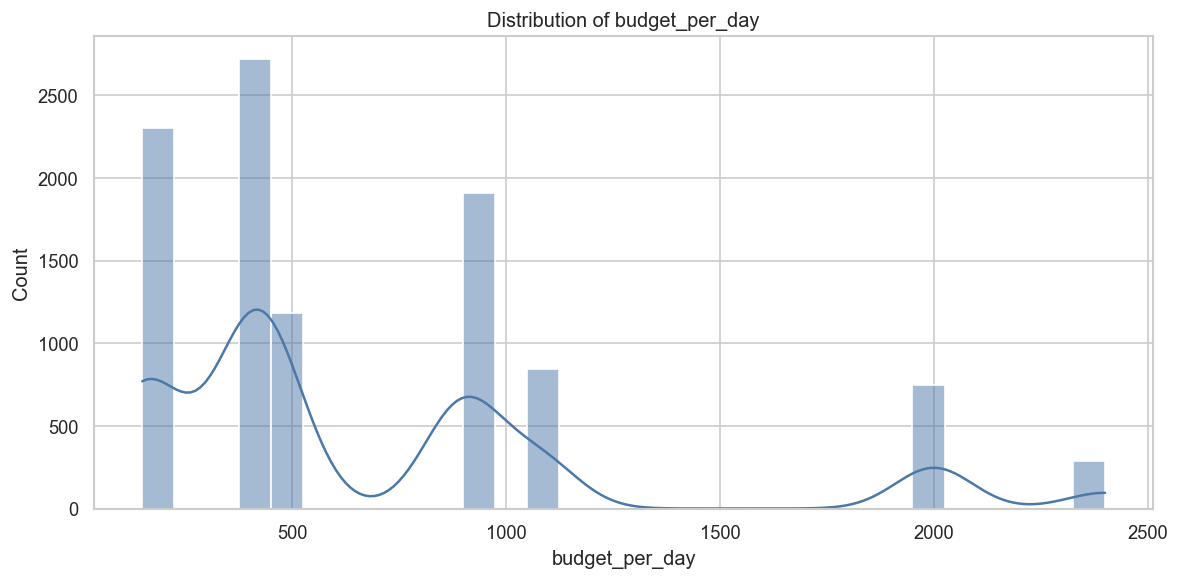

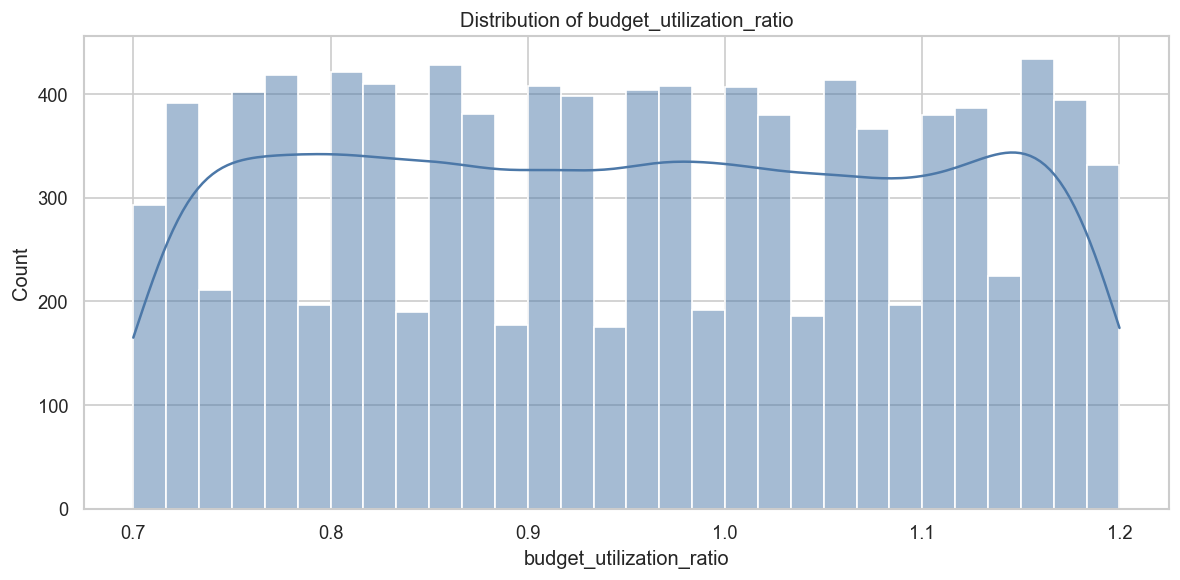

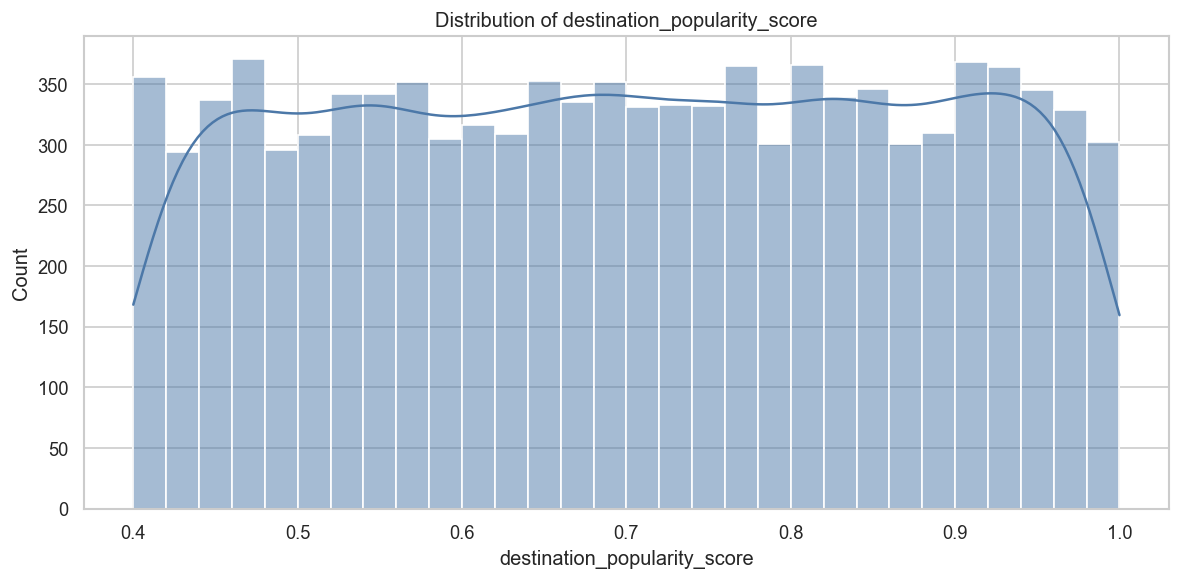

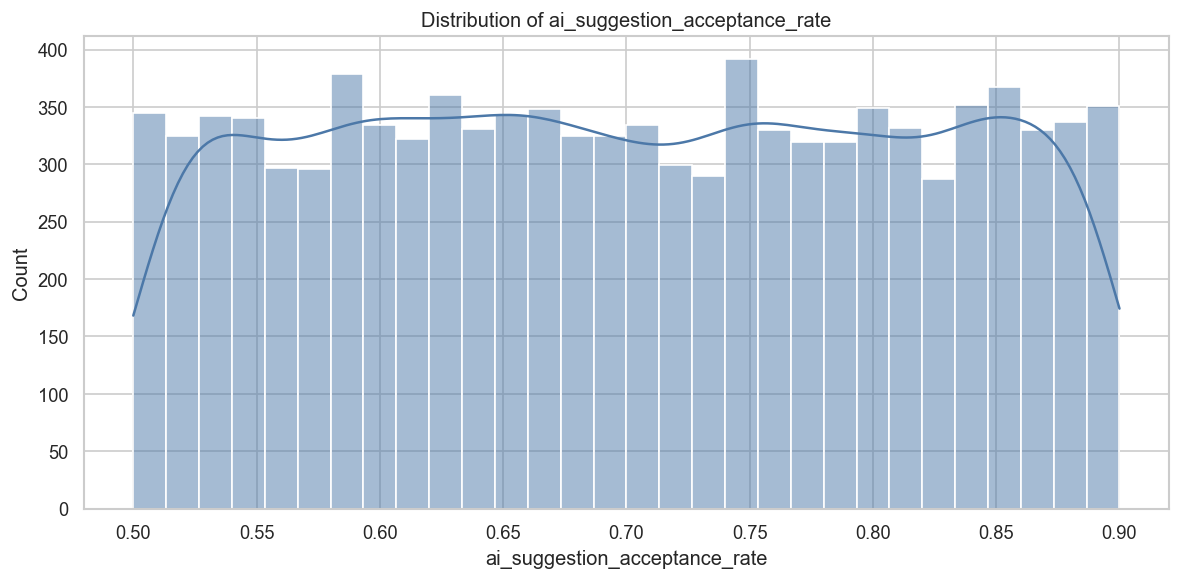

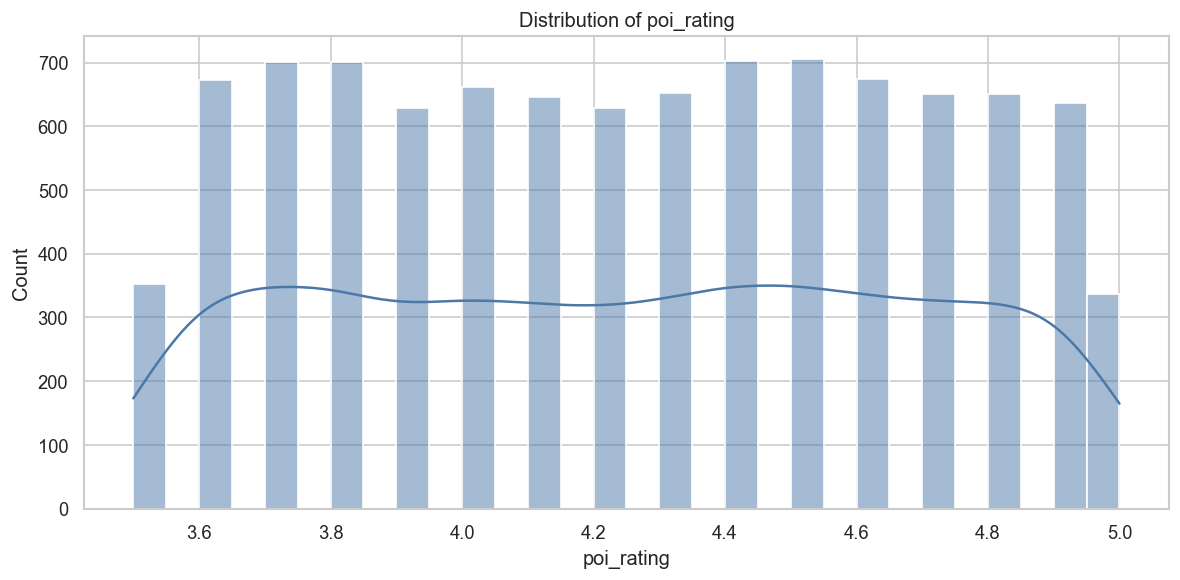

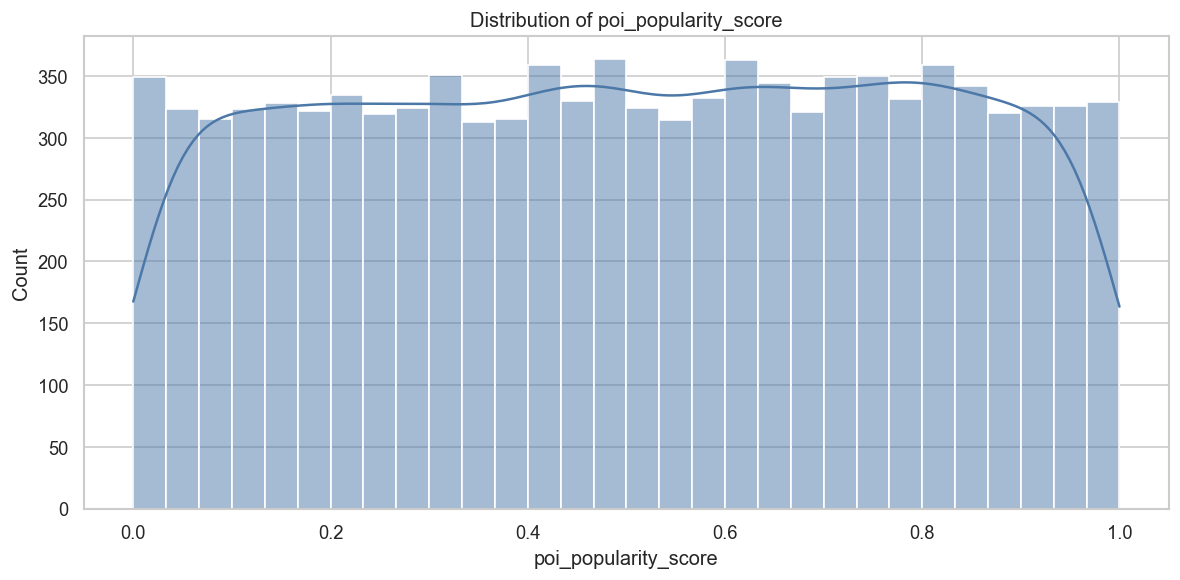

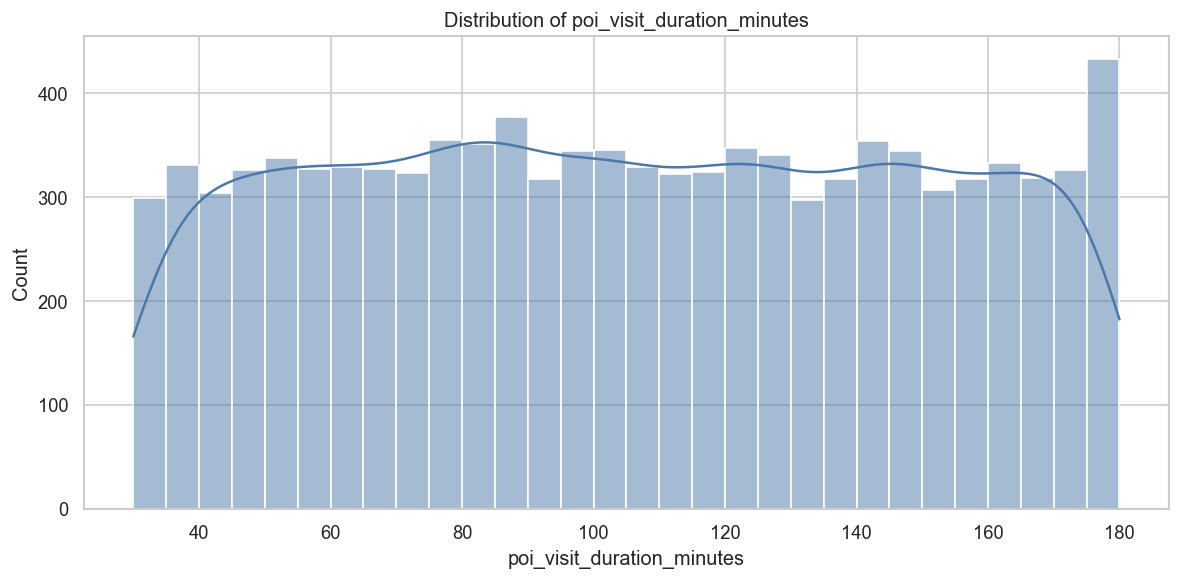

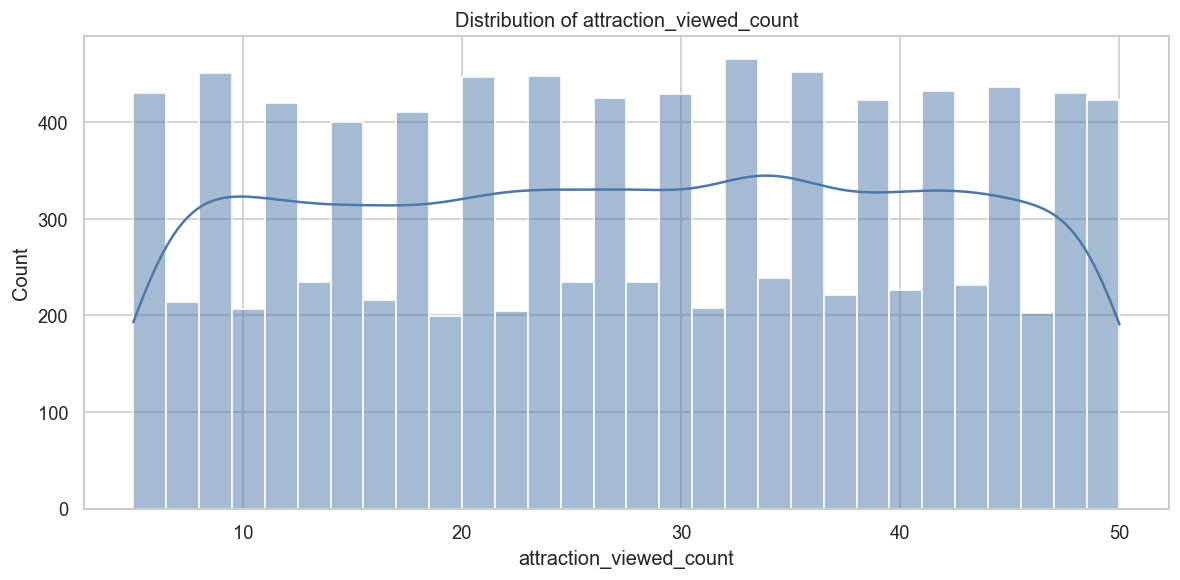

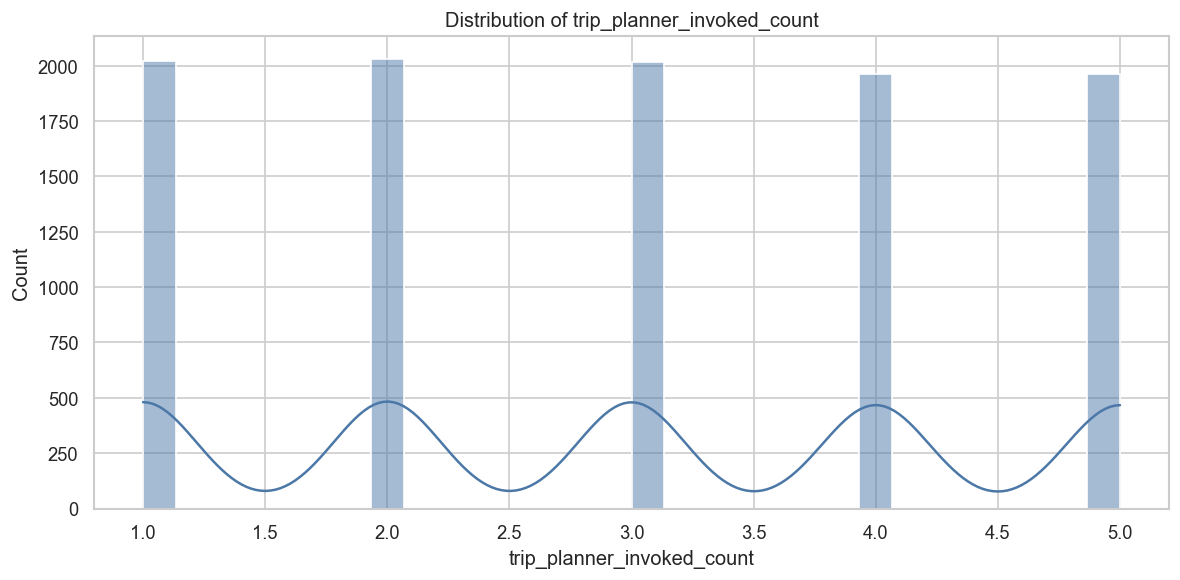

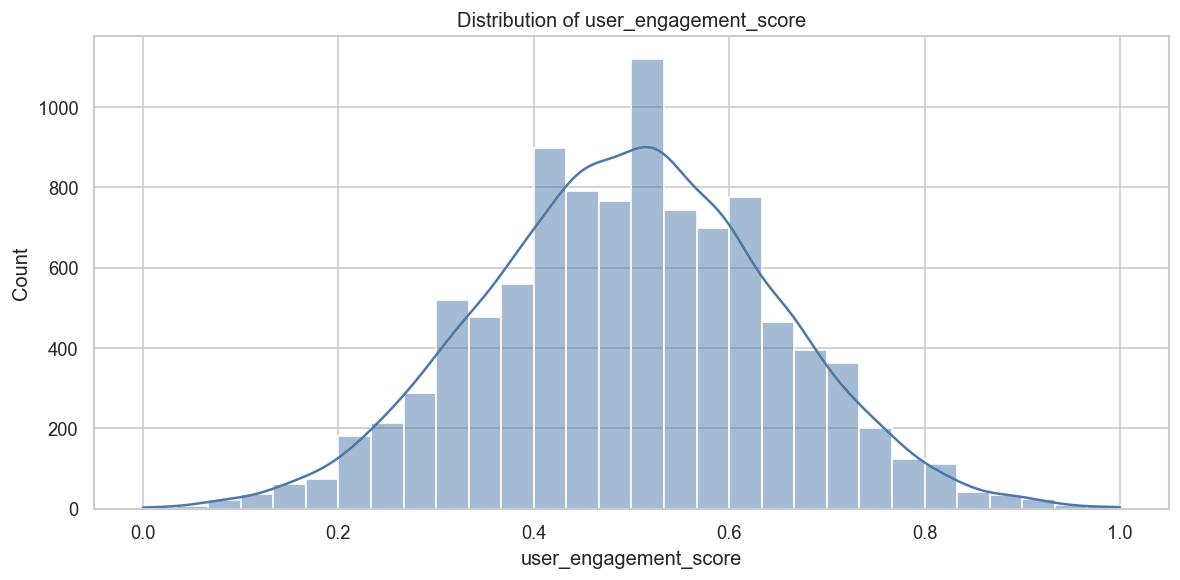

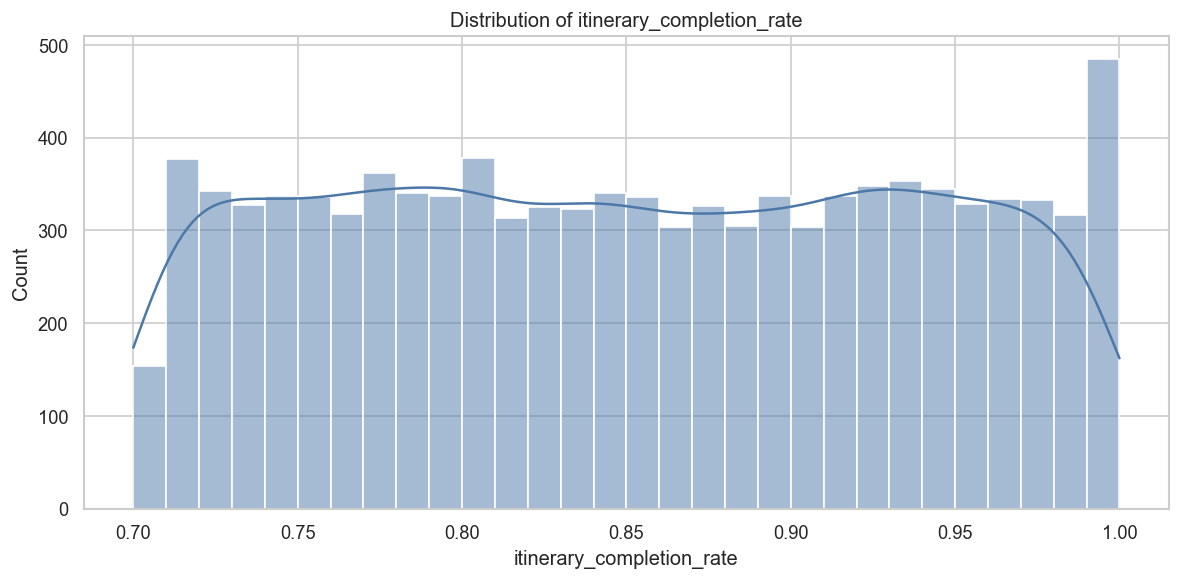

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=30, kde=True, color="#4c78a8")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    save_fig(f"hist_{col}")

### Box plots to compare numeric metrics across categories
Here we look at trip duration, budget per day, and total budget by destination type and budget tier.

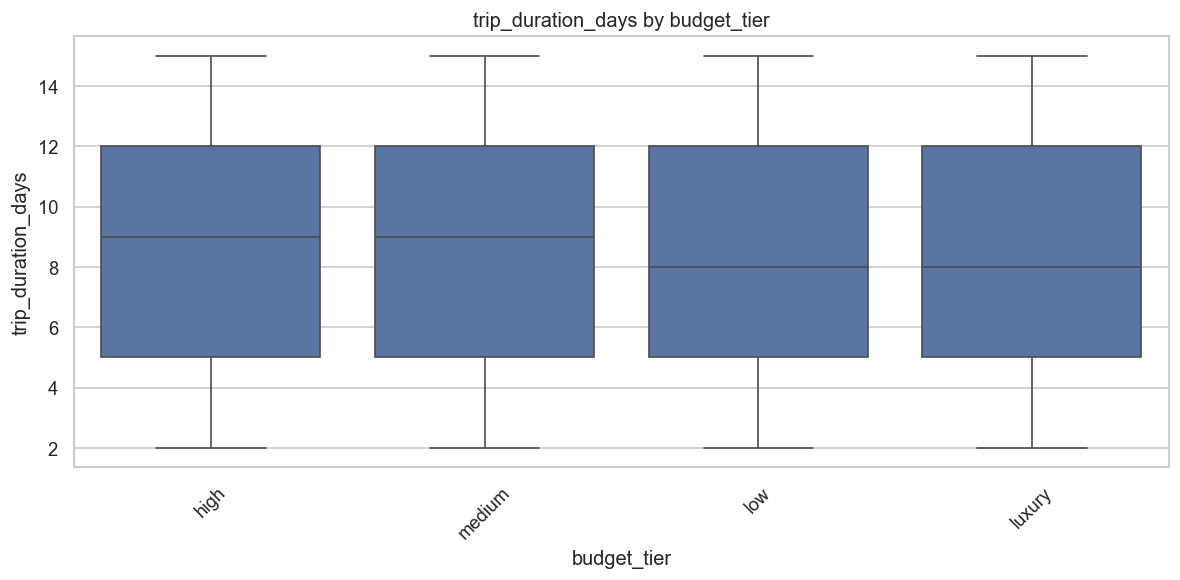

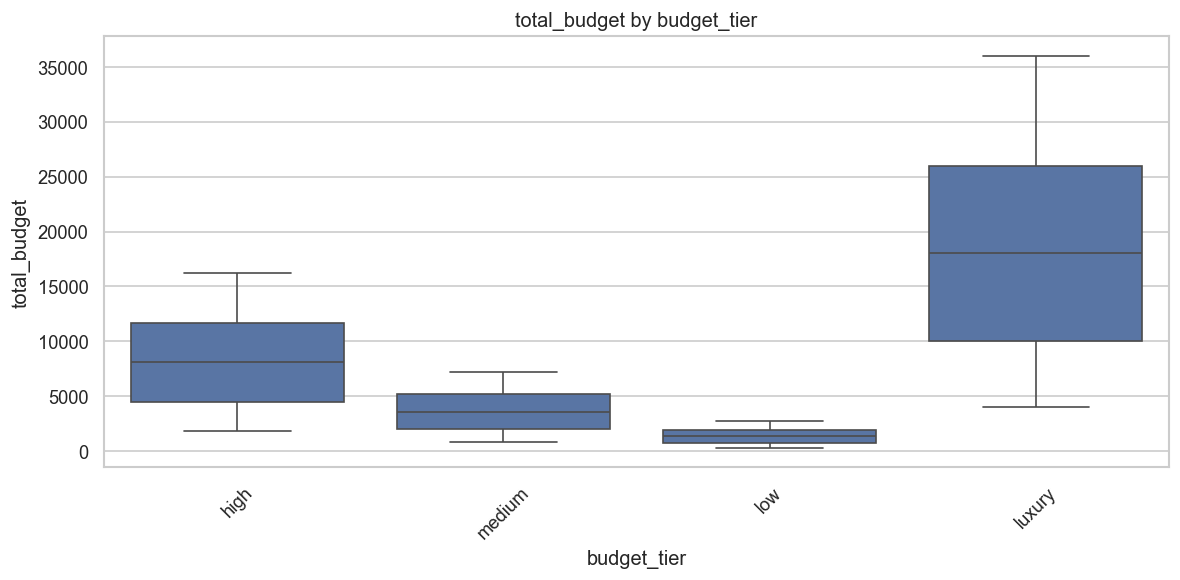

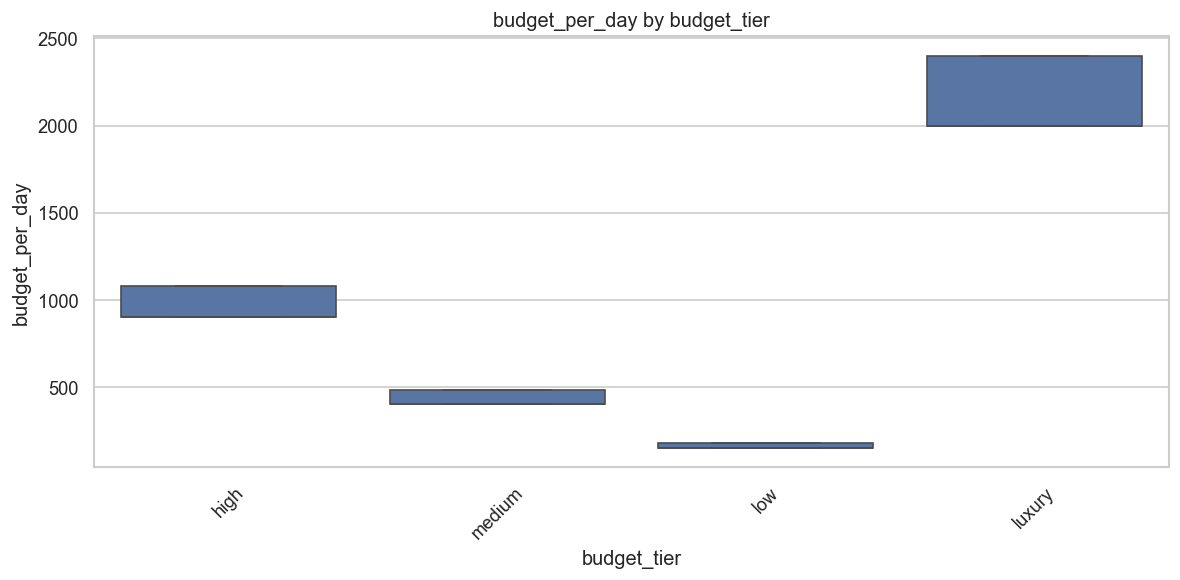

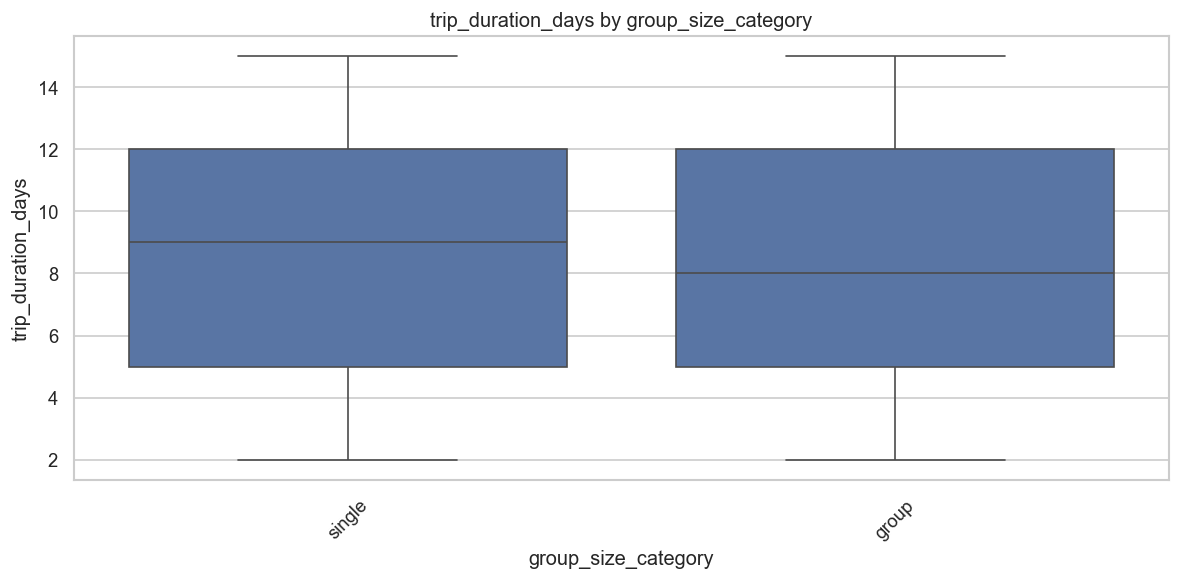

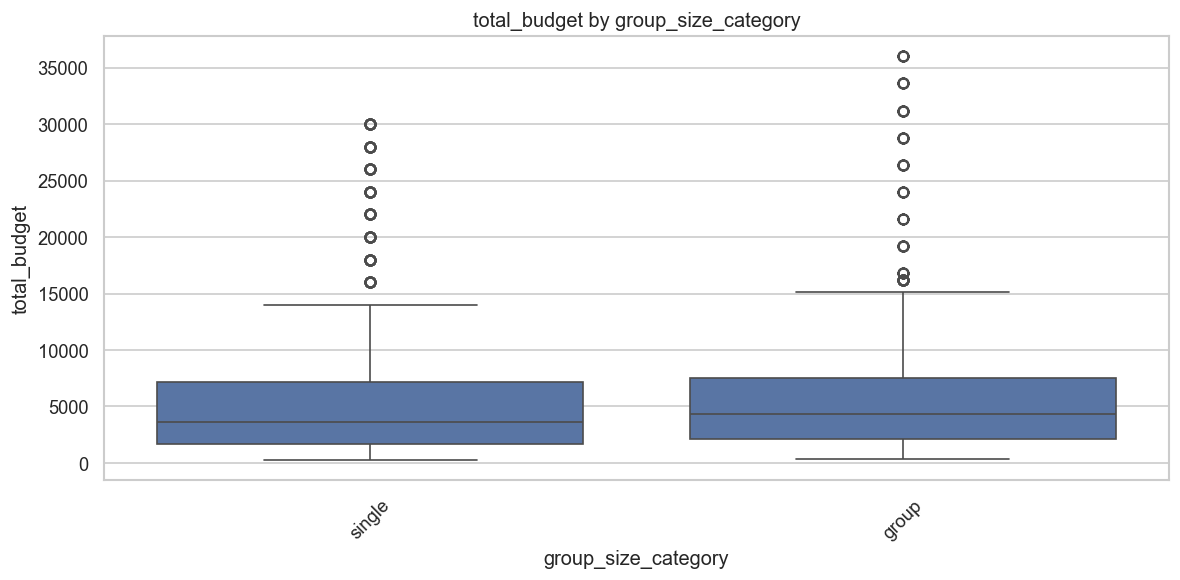

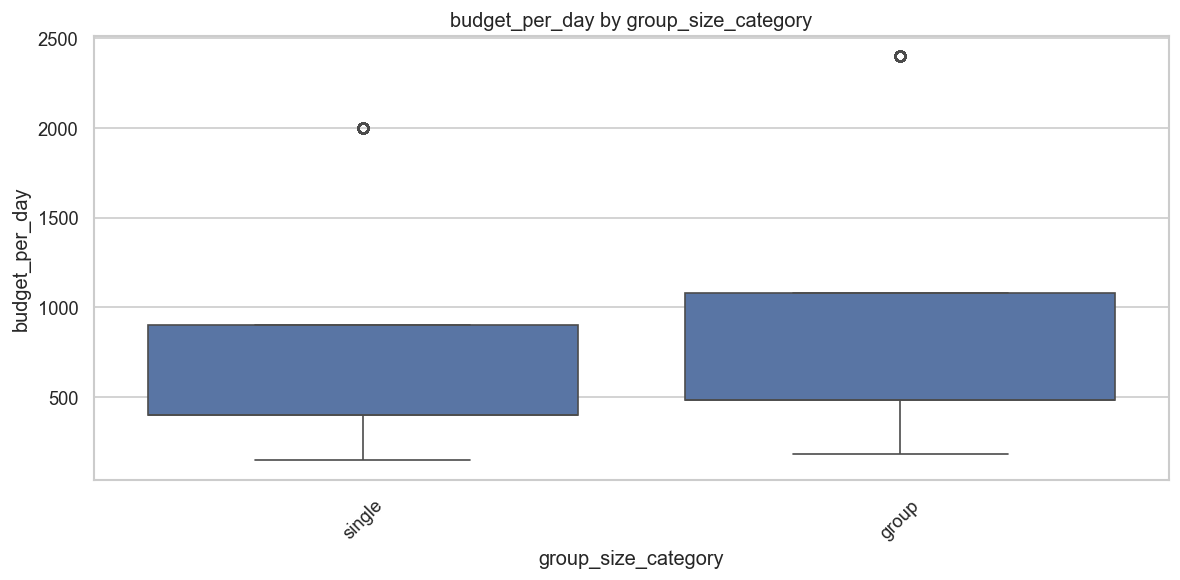

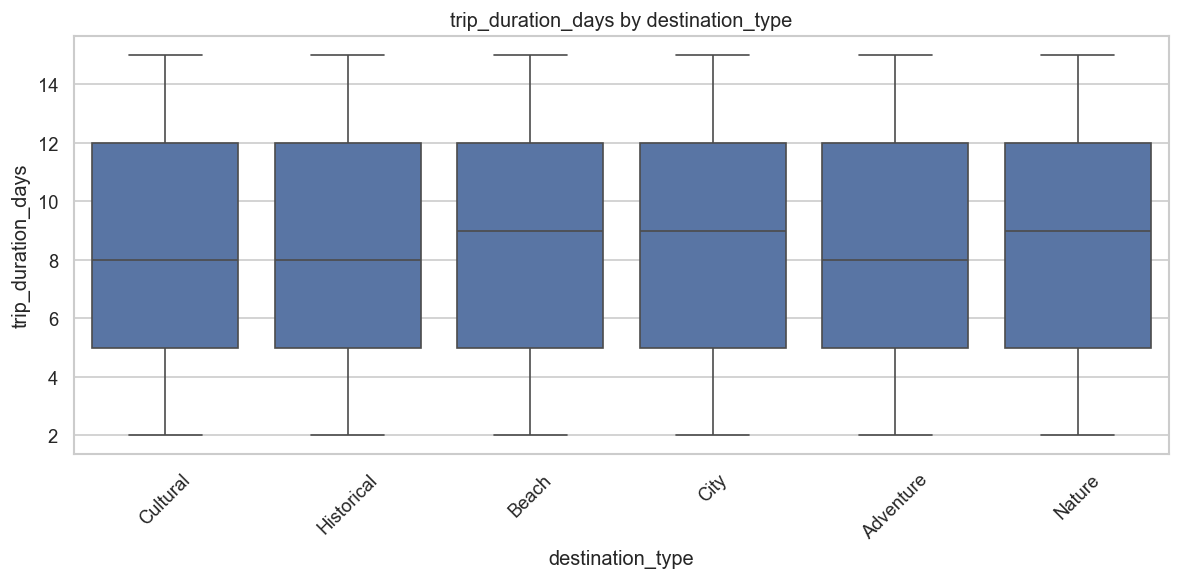

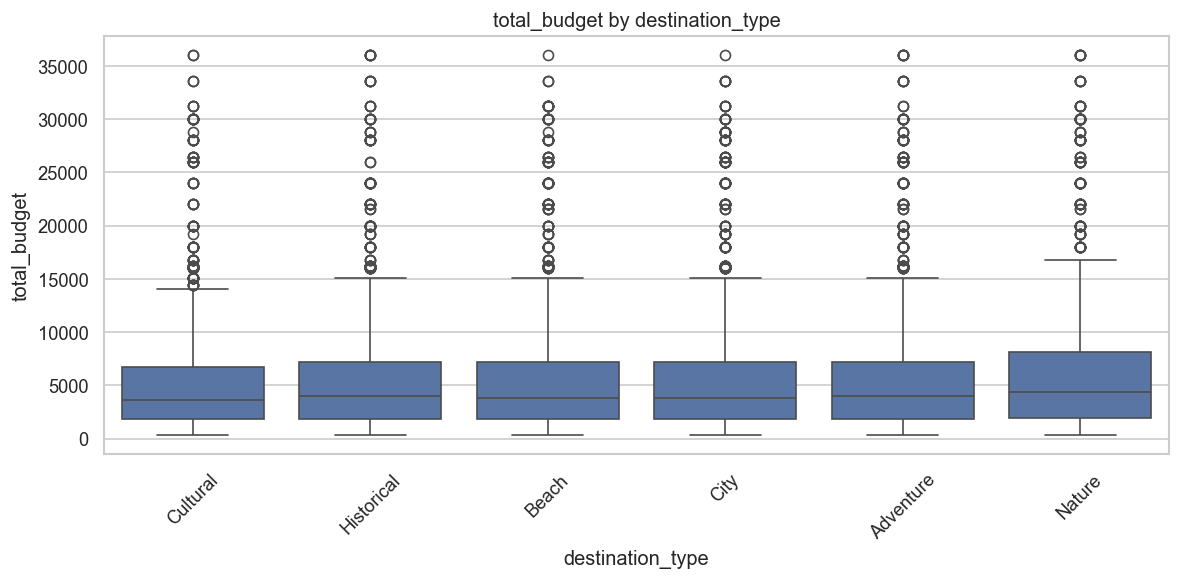

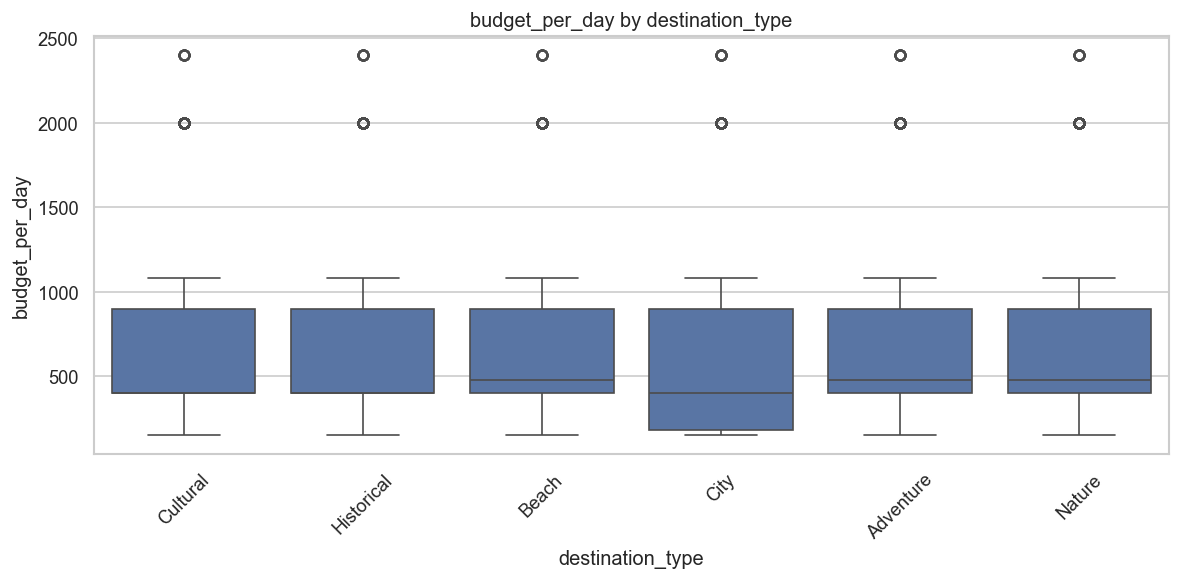

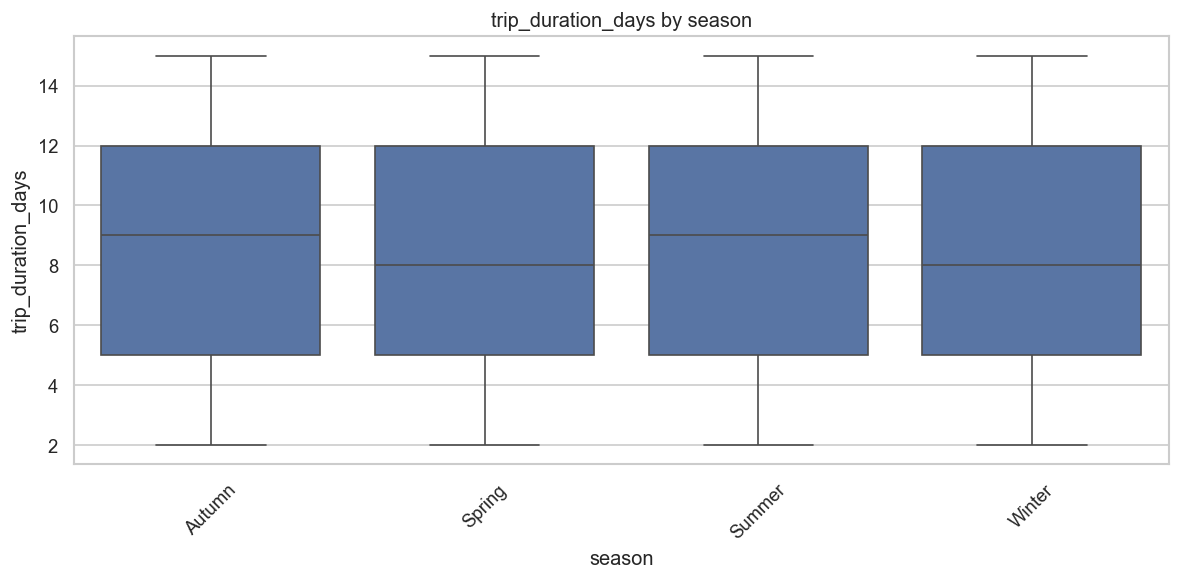

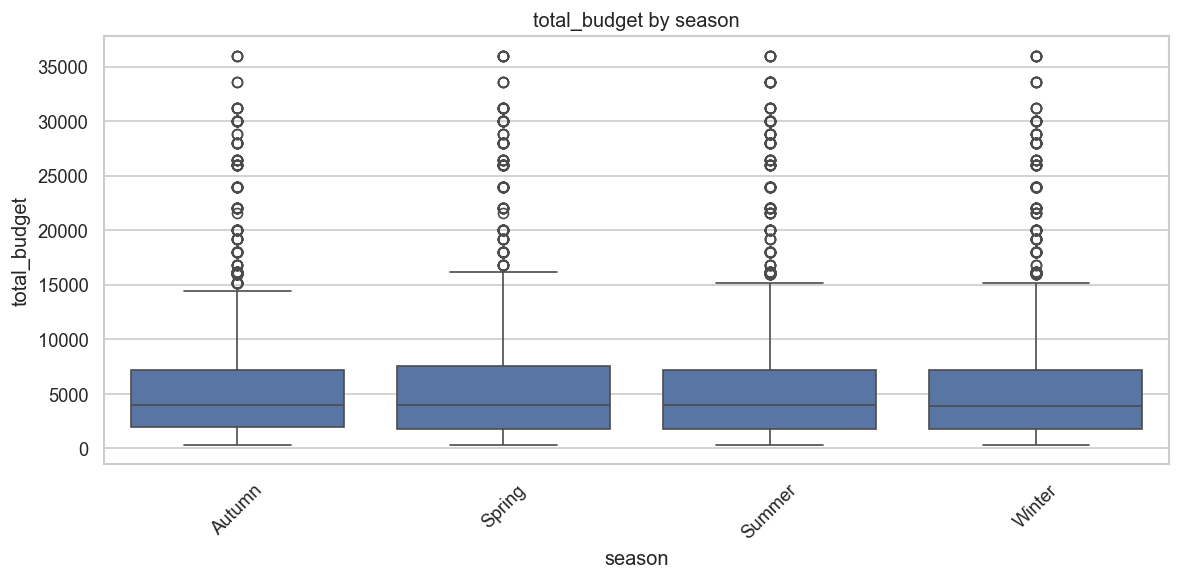

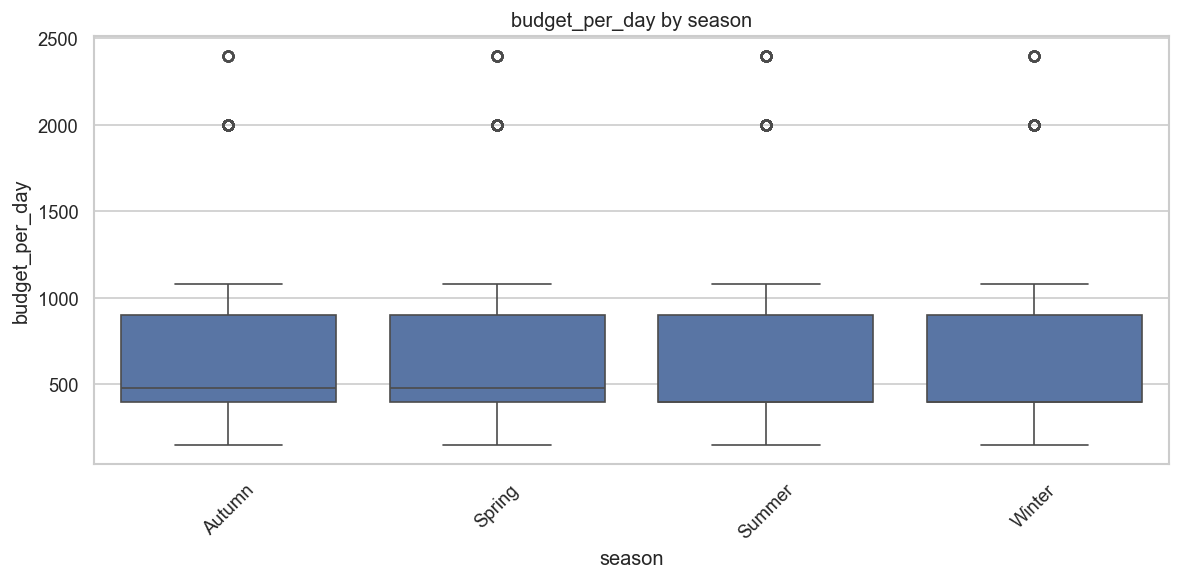

In [7]:
categorical_vars = ['budget_tier', 'group_size_category', 'destination_type', 'season']
numeric_pickers = ['trip_duration_days', 'total_budget', 'budget_per_day']

for cat in categorical_vars:
    for num in numeric_pickers:
        plt.figure()
        sns.boxplot(x=cat, y=num, data=df)
        plt.title(f"{num} by {cat}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        save_fig(f"box_{num}_by_{cat}")

### Bar charts for categories
These show how many rows fall into each category (budget tier, transport mode, etc.).

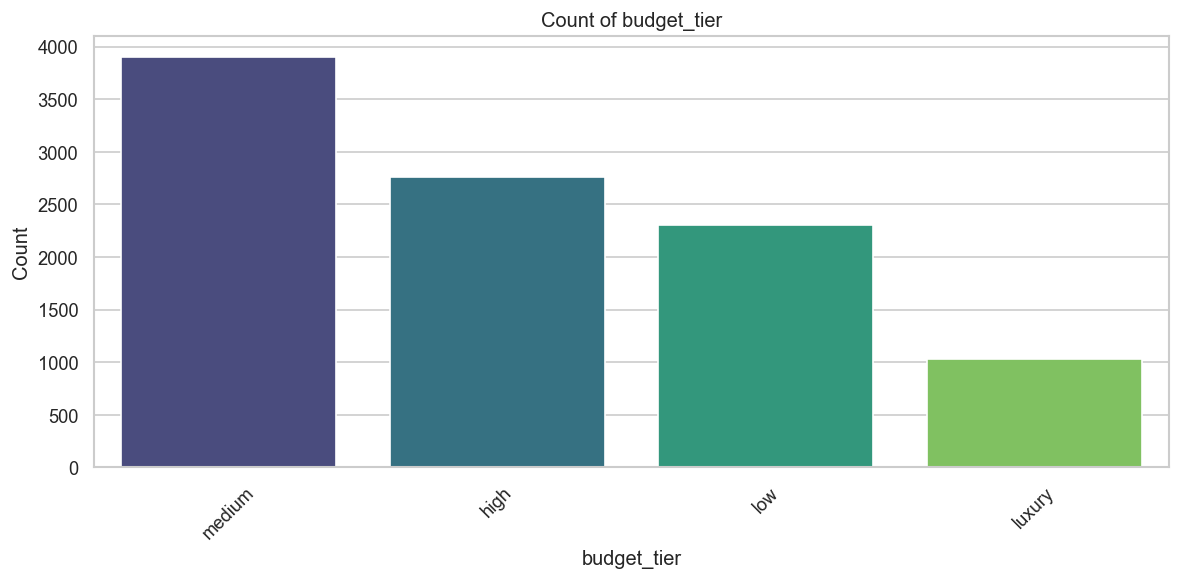

In [8]:
# Bar chart: Budget Tier
counts = df['budget_tier'].value_counts()
plot_df = counts.rename_axis('budget_tier').reset_index(name='count')
plt.figure()
sns.barplot(data=plot_df, x='budget_tier', y='count', hue='budget_tier',
            palette='viridis', legend=False, dodge=False)
plt.title('Count of budget_tier')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
save_fig('bar_budget_tier')

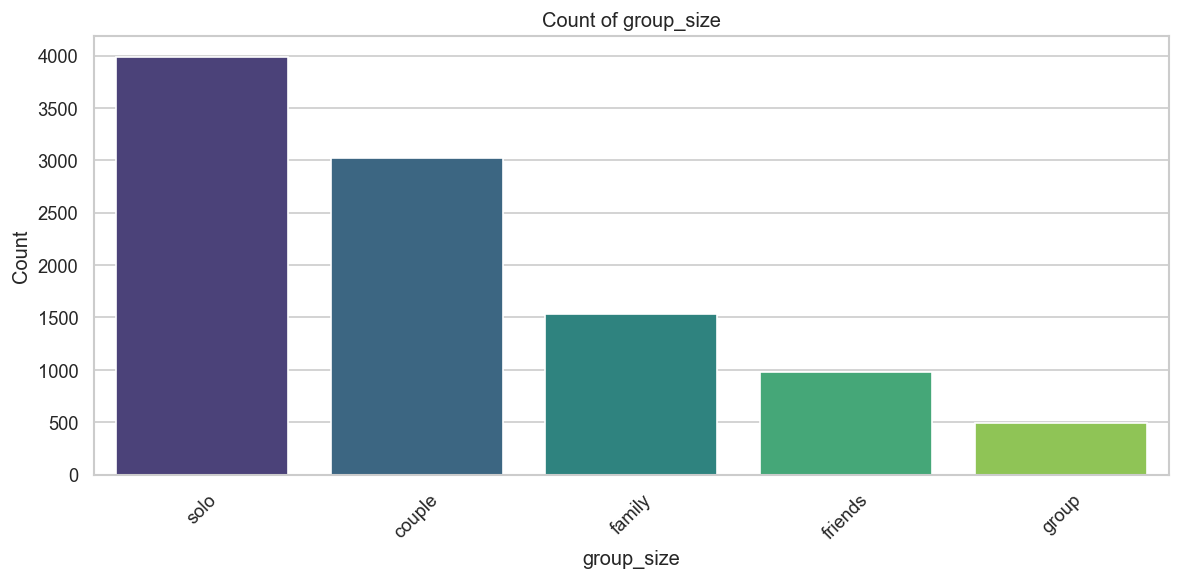

In [9]:
# Bar chart: Group Size
counts = df['group_size'].value_counts()
plot_df = counts.rename_axis('group_size').reset_index(name='count')
plt.figure()
sns.barplot(data=plot_df, x='group_size', y='count', hue='group_size',
            palette='viridis', legend=False, dodge=False)
plt.title('Count of group_size')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
save_fig('bar_group_size')

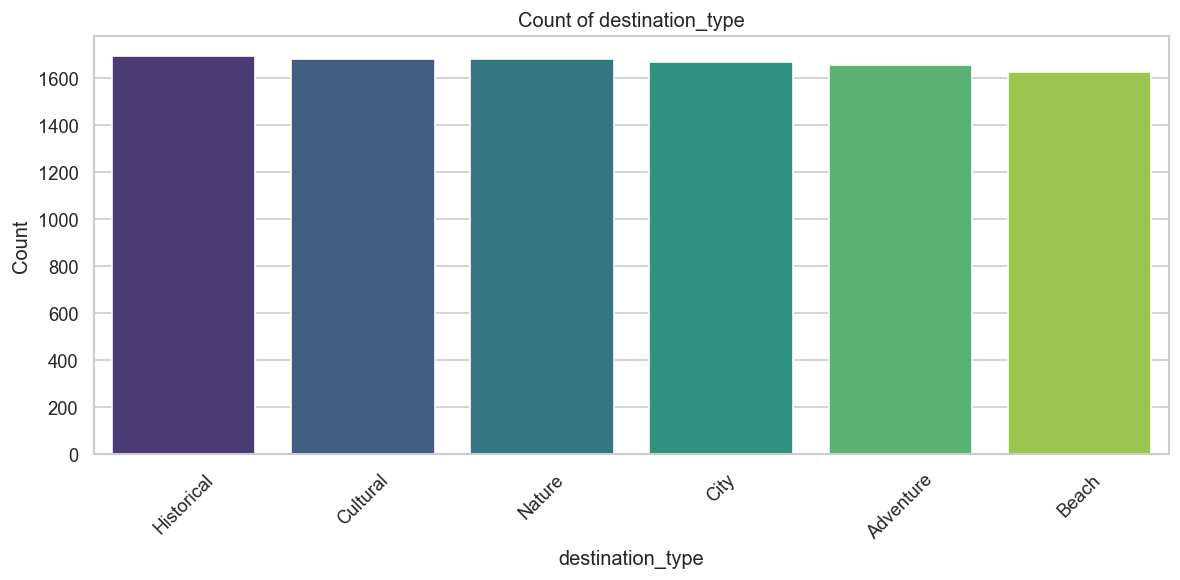

In [10]:
# Bar chart: Destination Type
counts = df['destination_type'].value_counts()
plot_df = counts.rename_axis('destination_type').reset_index(name='count')
plt.figure()
sns.barplot(data=plot_df, x='destination_type', y='count', hue='destination_type',
            palette='viridis', legend=False, dodge=False)
plt.title('Count of destination_type')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
save_fig('bar_destination_type')

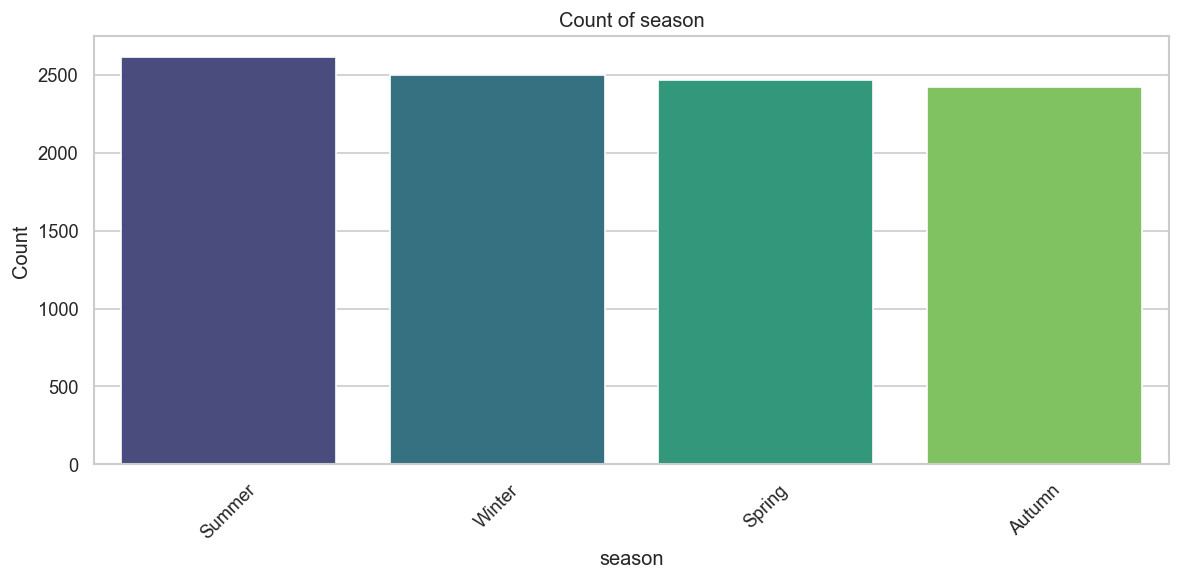

In [11]:
# Bar chart: Season
counts = df['season'].value_counts()
plot_df = counts.rename_axis('season').reset_index(name='count')
plt.figure()
sns.barplot(data=plot_df, x='season', y='count', hue='season',
            palette='viridis', legend=False, dodge=False)
plt.title('Count of season')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
save_fig('bar_season')

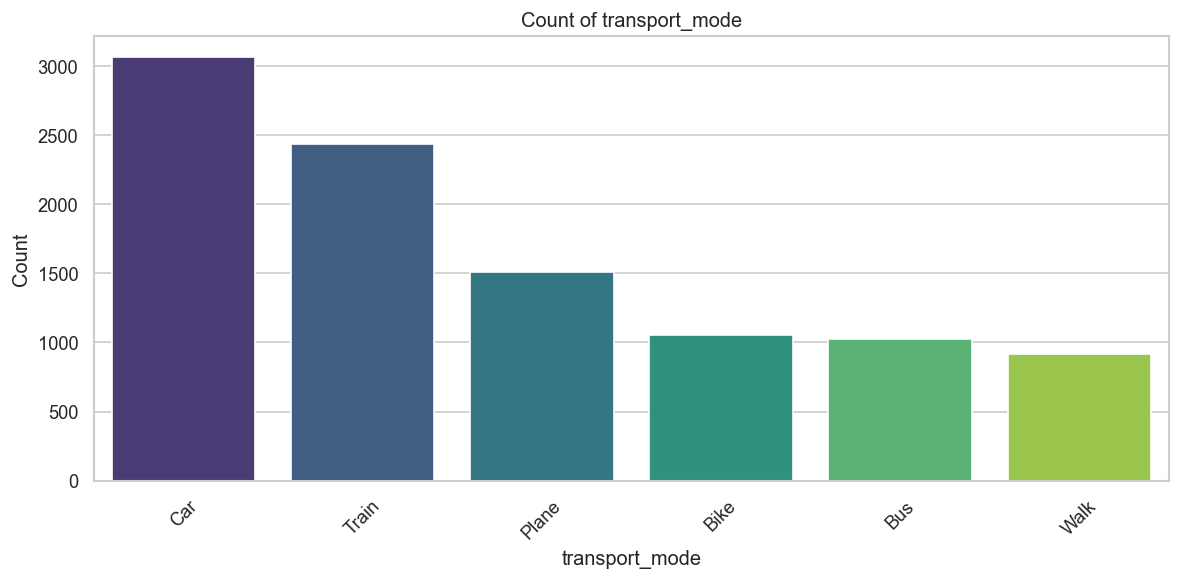

In [12]:
# Bar chart: Transport Mode
counts = df['transport_mode'].value_counts()
plot_df = counts.rename_axis('transport_mode').reset_index(name='count')
plt.figure()
sns.barplot(data=plot_df, x='transport_mode', y='count', hue='transport_mode',
            palette='viridis', legend=False, dodge=False)
plt.title('Count of transport_mode')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
save_fig('bar_transport_mode')

### Correlation matrix
Shows how numeric columns correlate.
The top‑5 positive and negative correlations are printed as well.

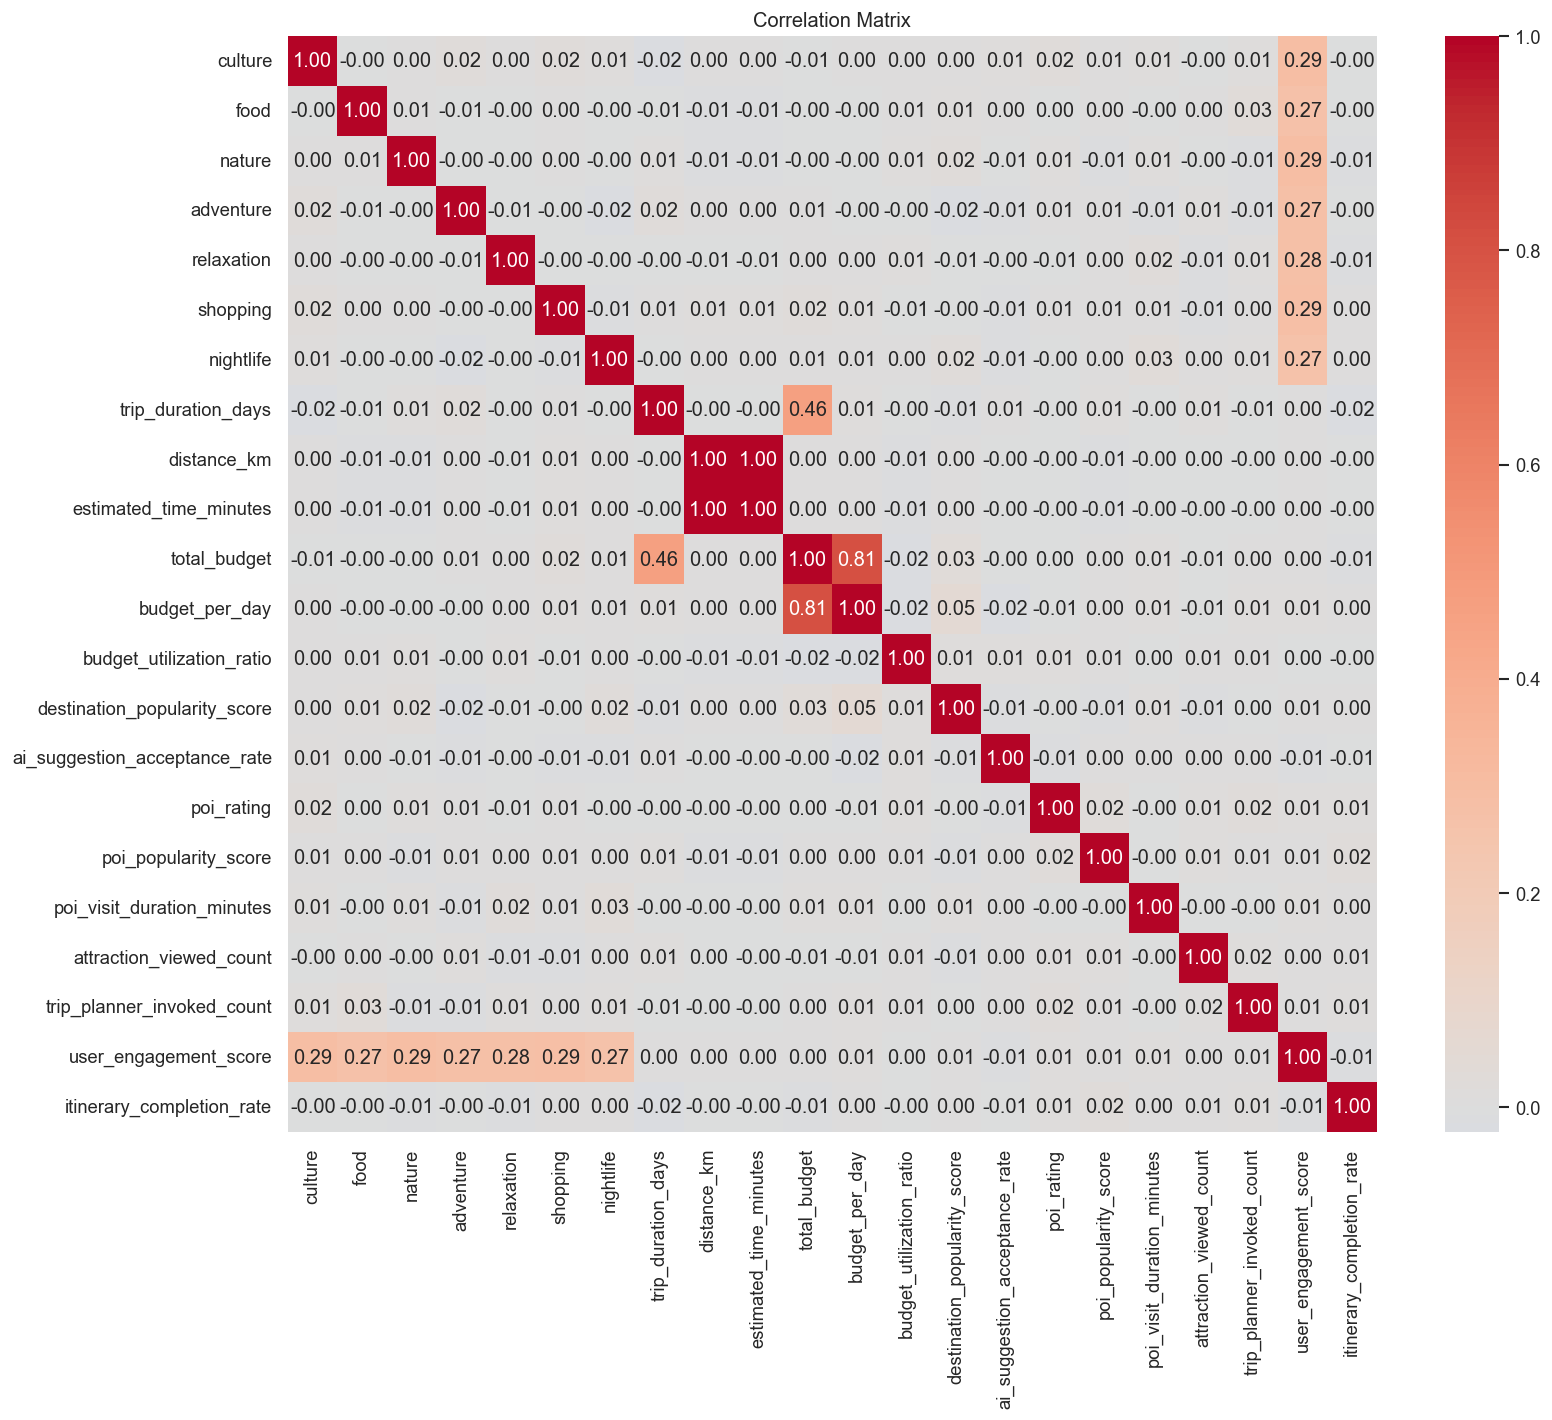


=== Top 5 positive correlations ===
distance_km             estimated_time_minutes    0.997
estimated_time_minutes  distance_km               0.997
budget_per_day          total_budget              0.806
total_budget            budget_per_day            0.806
                        trip_duration_days        0.462
dtype: float64

=== Top 5 negative correlations ===
trip_duration_days        itinerary_completion_rate   -0.021
budget_per_day            budget_utilization_ratio    -0.022
budget_utilization_ratio  budget_per_day              -0.022
nightlife                 adventure                   -0.023
adventure                 nightlife                   -0.023
dtype: float64


In [13]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
save_fig('correlation_matrix')

# Top 5 positive & negative corr pairs
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
top5 = corr_pairs[(corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1))][:5]
bot5 = corr_pairs.tail(5)

print('\n=== Top 5 positive correlations ===')
print(top5.round(3))
print('\n=== Top 5 negative correlations ===')
print(bot5.round(3))

### Group‑by summaries
- Average budget per day by destination type
- Avg trip duration by group size category
- Avg user engagement by season
- Avg budget utilization by budget tier


--- Avg Budget Per Day By Destination ---
destination_type
Adventure     704.37
Beach         678.21
City          682.30
Cultural      656.23
Historical    679.68
Nature        702.26
Name: budget_per_day, dtype: float64


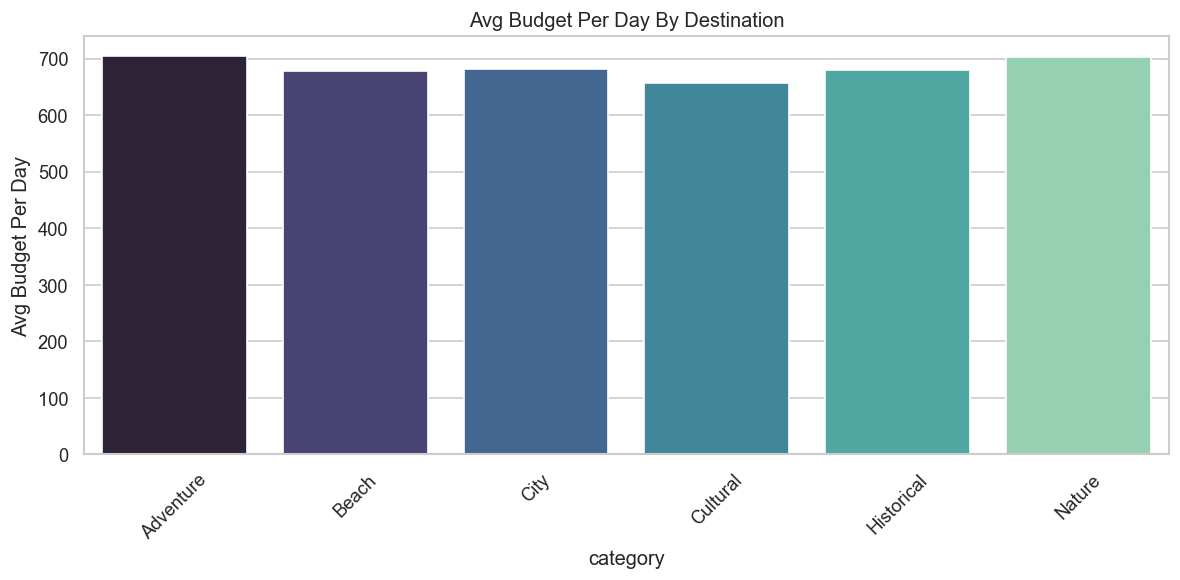

In [14]:
# Group-by: Avg Budget Per Day by Destination Type
series = df.groupby('destination_type')['budget_per_day'].mean()
print('\n--- Avg Budget Per Day By Destination ---')
print(series.round(2))
plot_df = series.rename_axis('category').reset_index(name='value')
plt.figure()
sns.barplot(data=plot_df, x='category', y='value', hue='category',
            palette='mako', legend=False, dodge=False)
plt.title('Avg Budget Per Day By Destination')
plt.ylabel('Avg Budget Per Day')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('avg_budget_per_day_by_destination')


--- Avg Trip Duration By Group Size ---
group_size_category
group     8.56
single    8.49
Name: trip_duration_days, dtype: float64


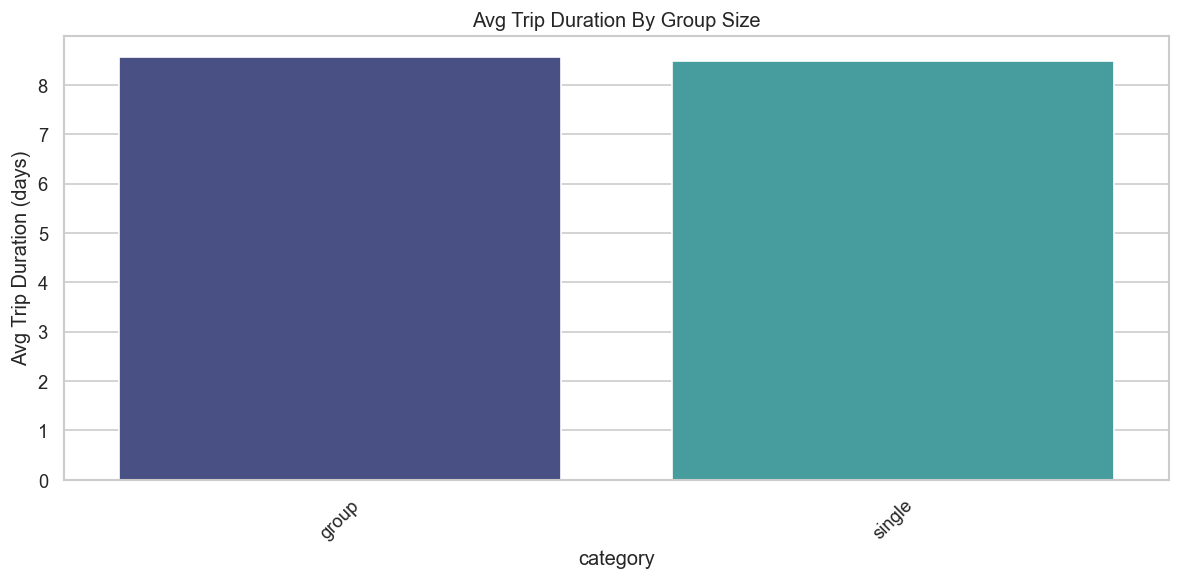

In [15]:
# Group-by: Avg Trip Duration by Group Size
series = df.groupby('group_size_category')['trip_duration_days'].mean()
print('\n--- Avg Trip Duration By Group Size ---')
print(series.round(2))
plot_df = series.rename_axis('category').reset_index(name='value')
plt.figure()
sns.barplot(data=plot_df, x='category', y='value', hue='category',
            palette='mako', legend=False, dodge=False)
plt.title('Avg Trip Duration By Group Size')
plt.ylabel('Avg Trip Duration (days)')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('avg_trip_duration_by_group_size')


--- Avg User Engagement By Season ---
season
Autumn    0.5
Spring    0.5
Summer    0.5
Winter    0.5
Name: user_engagement_score, dtype: float64


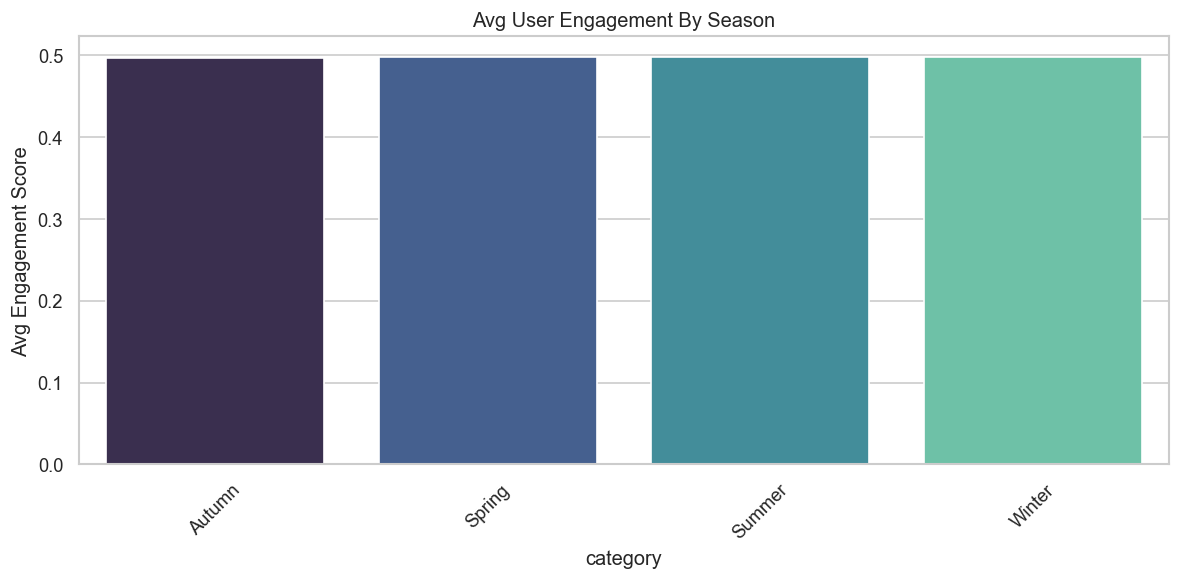

In [16]:
# Group-by: Avg User Engagement by Season
series = df.groupby('season')['user_engagement_score'].mean()
print('\n--- Avg User Engagement By Season ---')
print(series.round(2))
plot_df = series.rename_axis('category').reset_index(name='value')
plt.figure()
sns.barplot(data=plot_df, x='category', y='value', hue='category',
            palette='mako', legend=False, dodge=False)
plt.title('Avg User Engagement By Season')
plt.ylabel('Avg Engagement Score')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('avg_user_engagement_by_season')


--- Budget Utilization Ratio By Tier ---
budget_tier
high      0.95
low       0.95
luxury    0.94
medium    0.95
Name: budget_utilization_ratio, dtype: float64


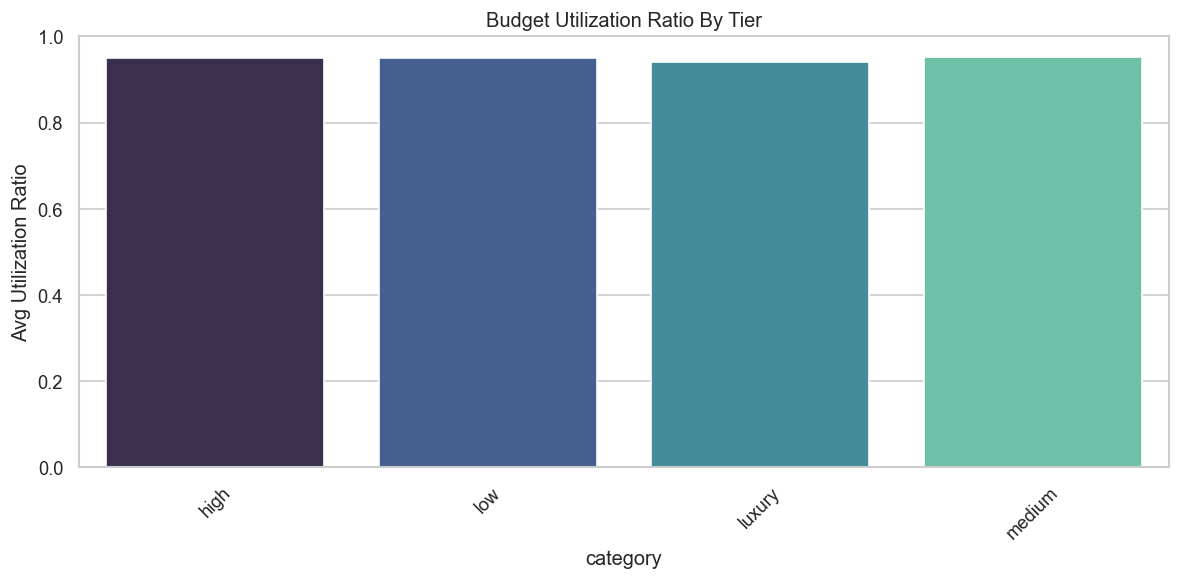

In [17]:
# Group-by: Budget Utilization Ratio by Tier
series = df.groupby('budget_tier')['budget_utilization_ratio'].mean()
print('\n--- Budget Utilization Ratio By Tier ---')
print(series.round(2))
plot_df = series.rename_axis('category').reset_index(name='value')
plt.figure()
sns.barplot(data=plot_df, x='category', y='value', hue='category',
            palette='mako', legend=False, dodge=False)
plt.title('Budget Utilization Ratio By Tier')
plt.ylabel('Avg Utilization Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('budget_utilization_ratio_by_tier')

### Distributions of key ratios and binary flags
Histograms are useful for quick sanity checks.

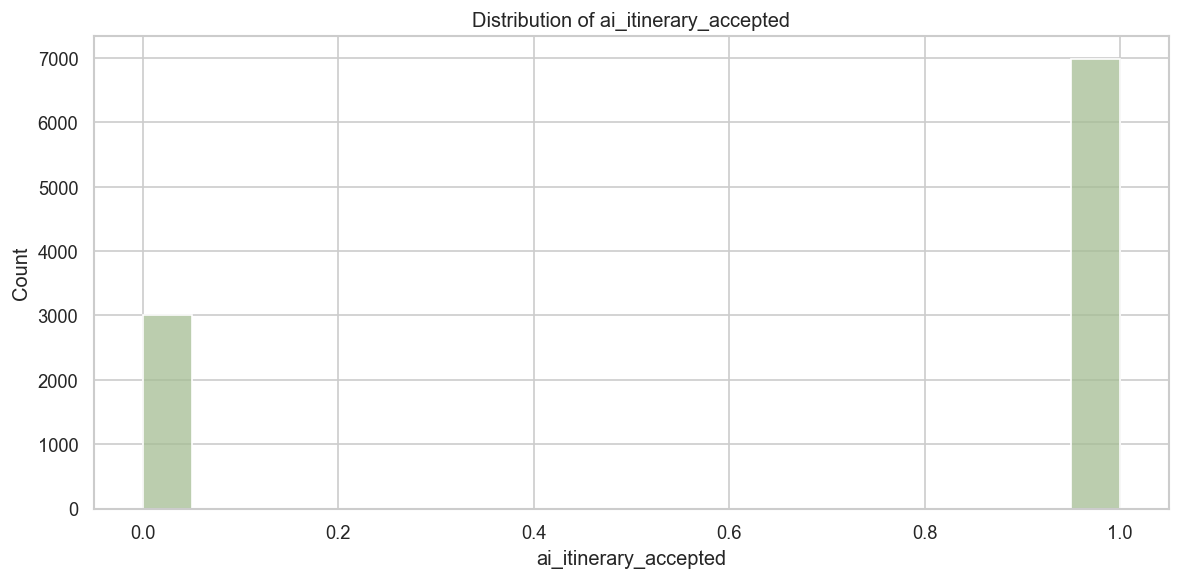

In [18]:
# Distribution: ai_itinerary_accepted
plt.figure()
sns.histplot(df['ai_itinerary_accepted'].dropna(), bins=20, kde=False, color='#a5bd93')
plt.title('Distribution of ai_itinerary_accepted')
plt.xlabel('ai_itinerary_accepted')
plt.ylabel('Count')
plt.tight_layout()
save_fig('hist_ai_itinerary_accepted')

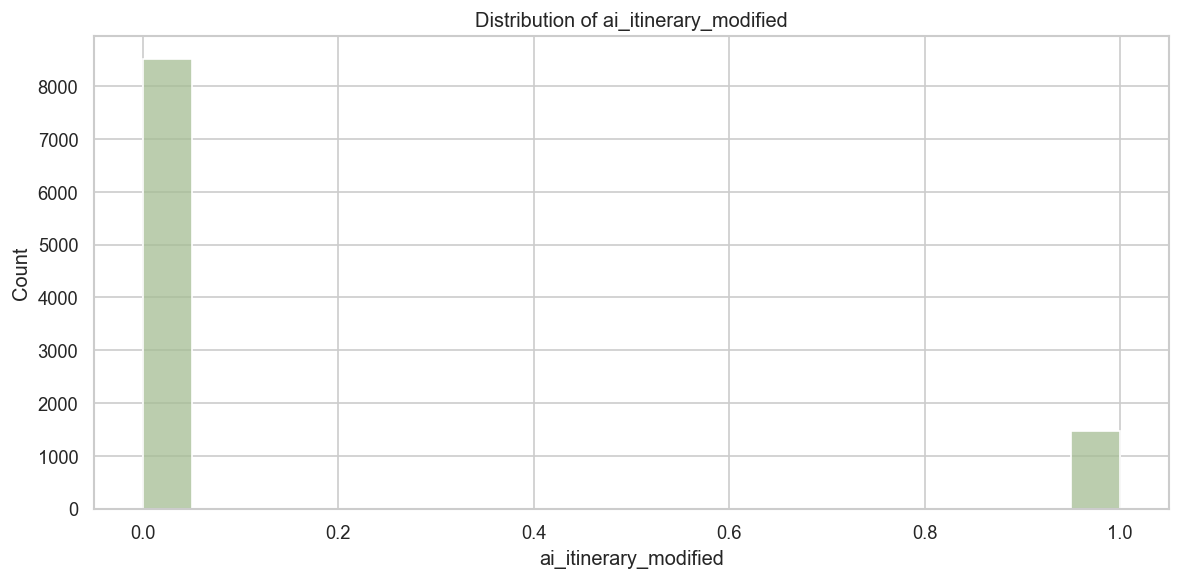

In [19]:
# Distribution: ai_itinerary_modified
plt.figure()
sns.histplot(df['ai_itinerary_modified'].dropna(), bins=20, kde=False, color='#a5bd93')
plt.title('Distribution of ai_itinerary_modified')
plt.xlabel('ai_itinerary_modified')
plt.ylabel('Count')
plt.tight_layout()
save_fig('hist_ai_itinerary_modified')

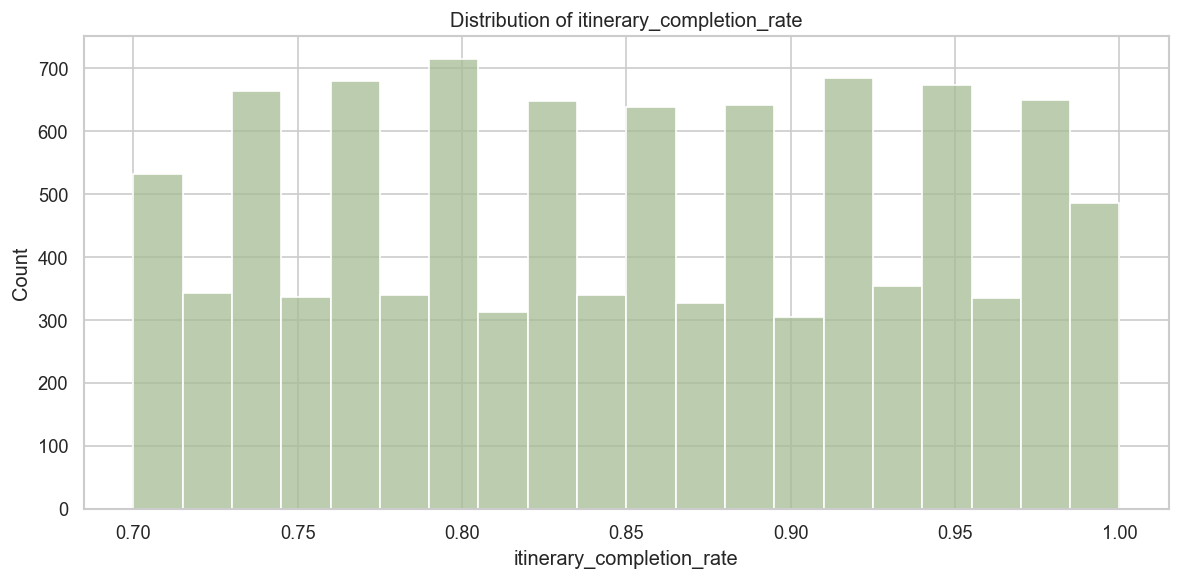

In [20]:
# Distribution: itinerary_completion_rate
plt.figure()
sns.histplot(df['itinerary_completion_rate'].dropna(), bins=20, kde=False, color='#a5bd93')
plt.title('Distribution of itinerary_completion_rate')
plt.xlabel('itinerary_completion_rate')
plt.ylabel('Count')
plt.tight_layout()
save_fig('hist_itinerary_completion_rate')

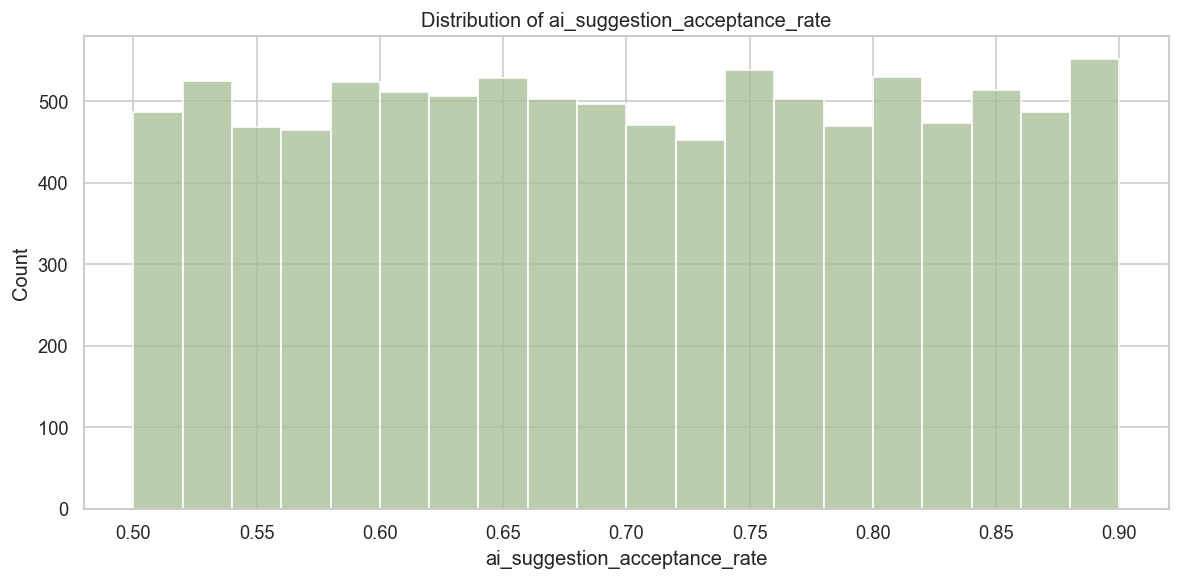

In [21]:
# Distribution: ai_suggestion_acceptance_rate
plt.figure()
sns.histplot(df['ai_suggestion_acceptance_rate'].dropna(), bins=20, kde=False, color='#a5bd93')
plt.title('Distribution of ai_suggestion_acceptance_rate')
plt.xlabel('ai_suggestion_acceptance_rate')
plt.ylabel('Count')
plt.tight_layout()
save_fig('hist_ai_suggestion_acceptance_rate')